# MoE Live Demo: Watch the Experts Light Up

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/prashantkul/learn-generative-ai/blob/main/10-mixture-of-experts/live-moe-demo.ipynb)

**GPU recommended:** Yes (model inference is faster on GPU). Use Colab's free T4.

This notebook loads a real MoE model and visualizes expert routing in action.
We'll see which experts activate for different tokens and input types.

---

## 1. Setup and Model Loading

In [1]:
!pip install -q transformers accelerate torch bitsandbytes sentencepiece seaborn scipy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.2 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics.pairwise import cosine_similarity

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "figure.dpi": 120,
})

sns.set_palette("husl")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.1 GB


In [3]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen1.5-MoE-A2.7B-Chat"
FALLBACK_MODEL_ID = "mistralai/Mixtral-8x7B-v0.1"

model = None
tokenizer = None
model_name = None

# Attempt 1: Load Qwen1.5-MoE-A2.7B-Chat in float16
try:
    print(f"Loading {MODEL_ID} ...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True,
    )
    model_name = MODEL_ID
    print(f"Successfully loaded {MODEL_ID}")
except Exception as e:
    print(f"Failed to load {MODEL_ID}: {e}")
    print(f"\nFalling back to {FALLBACK_MODEL_ID} with 4-bit quantization ...")
    try:
        from transformers import BitsAndBytesConfig
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_quant_type="nf4",
        )
        tokenizer = AutoTokenizer.from_pretrained(FALLBACK_MODEL_ID)
        model = AutoModelForCausalLM.from_pretrained(
            FALLBACK_MODEL_ID,
            quantization_config=bnb_config,
            device_map="auto",
        )
        model_name = FALLBACK_MODEL_ID
        print(f"Successfully loaded {FALLBACK_MODEL_ID} (4-bit)")
    except Exception as e2:
        raise RuntimeError(
            f"Could not load either model. "
            f"Primary: {e}. Fallback: {e2}. "
            f"Try using a GPU runtime with more memory."
        )

model.eval()
print(f"\nModel: {model_name}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

Loading Qwen/Qwen1.5-MoE-A2.7B-Chat ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/387 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/248 [00:00<?, ?B/s]

Successfully loaded Qwen/Qwen1.5-MoE-A2.7B-Chat

Model: Qwen/Qwen1.5-MoE-A2.7B-Chat
Total parameters: 14.32B


In [4]:
# Print a summary of the model architecture
print("Model architecture (top-level modules):")
print("=" * 60)
for name, module in model.named_children():
    num_params = sum(p.numel() for p in module.parameters()) / 1e6
    print(f"  {name}: {module.__class__.__name__} ({num_params:.1f}M params)")

print("\nFirst transformer layer structure:")
print("-" * 60)
first_layer = list(model.model.layers)[0]
for name, module in first_layer.named_children():
    num_params = sum(p.numel() for p in module.parameters()) / 1e6
    print(f"  {name}: {module.__class__.__name__} ({num_params:.1f}M params)")

Model architecture (top-level modules):
  model: Qwen2MoeModel (14004.6M params)
  lm_head: Linear (311.2M params)

First transformer layer structure:
------------------------------------------------------------
  self_attn: Qwen2MoeAttention (16.8M params)
  mlp: Qwen2MoeSparseMoeBlock (553.8M params)
  input_layernorm: Qwen2MoeRMSNorm (0.0M params)
  post_attention_layernorm: Qwen2MoeRMSNorm (0.0M params)


---

## 2. Inspect the MoE Architecture

We identify all MoE layers in the model, locate the router (gate) modules,
and print key parameters: number of experts, active experts per token, and
expert dimensions.

In [5]:
def find_moe_layers(model):
    """
    Walk the model and find all MoE layers.
    Supports Qwen1.5-MoE (Qwen2MoeSparseMoeBlock) and Mixtral (MixtralSparseMoeBlock).
    Returns a list of (layer_index, moe_module, gate_module) tuples.
    """
    moe_layers = []

    for layer_idx, layer in enumerate(model.model.layers):
        mlp = layer.mlp
        class_name = mlp.__class__.__name__

        # Check if this is a sparse MoE block (vs a dense MLP)
        if "SparseMoe" in class_name or "MoE" in class_name:
            gate = getattr(mlp, "gate", None)
            if gate is not None:
                moe_layers.append((layer_idx, mlp, gate))
        elif hasattr(mlp, "gate"):
            moe_layers.append((layer_idx, mlp, mlp.gate))

    return moe_layers


moe_layers_info = find_moe_layers(model)
print(f"Found {len(moe_layers_info)} MoE layers out of {len(list(model.model.layers))} total layers")
print()

Found 24 MoE layers out of 24 total layers



In [6]:
# Examine the first MoE layer in detail
if moe_layers_info:
    layer_idx, moe_block, gate = moe_layers_info[0]

    print(f"MoE block class: {moe_block.__class__.__name__}")
    print(f"Gate class:      {gate.__class__.__name__}")
    print()

    # Gate weight shape reveals (num_experts, d_model)
    gate_weight = gate.weight
    num_experts_total = gate_weight.shape[0]
    d_model = gate_weight.shape[1]
    print(f"Gate weight shape: {gate_weight.shape}")
    print(f"  -> Number of experts: {num_experts_total}")
    print(f"  -> Hidden dimension (d_model): {d_model}")
    print()

    # Determine top-k from model config
    config = model.config
    top_k = getattr(config, "num_experts_per_tok", None)
    if top_k is None:
        top_k = getattr(config, "num_selected_experts", 2)
    print(f"Active experts per token (top-k): {top_k}")
    print(f"Total experts: {num_experts_total}")
    print(f"Sparsity: only {top_k}/{num_experts_total} = {100*top_k/num_experts_total:.1f}% of experts active per token")
    print()

    # Show expert structure
    experts_container = getattr(moe_block, "experts", None)
    if experts_container is not None:
        if hasattr(experts_container, '__len__'):
            first_expert = experts_container[0]
        else:
            first_expert = list(experts_container.children())[0]
        print(f"Expert structure ({first_expert.__class__.__name__}):")
        for name, param in first_expert.named_parameters():
            print(f"  {name}: {param.shape}")
        expert_params = sum(p.numel() for p in first_expert.parameters())
        print(f"  Parameters per expert: {expert_params / 1e6:.2f}M")
        print(f"  Active expert params per token: {expert_params * top_k / 1e6:.2f}M")

    # Check for shared expert
    shared_expert = getattr(moe_block, "shared_expert", None)
    if shared_expert is not None:
        shared_params = sum(p.numel() for p in shared_expert.parameters())
        print(f"\nShared expert: {shared_expert.__class__.__name__} ({shared_params / 1e6:.2f}M params)")
        print("  (The shared expert processes ALL tokens, in addition to the routed experts)")

MoE block class: Qwen2MoeSparseMoeBlock
Gate class:      Qwen2MoeTopKRouter

Gate weight shape: torch.Size([60, 2048])
  -> Number of experts: 60
  -> Hidden dimension (d_model): 2048

Active experts per token (top-k): 4
Total experts: 60
Sparsity: only 4/60 = 6.7% of experts active per token

Expert structure (SiLUActivation):
  Parameters per expert: 0.00M
  Active expert params per token: 0.00M

Shared expert: Qwen2MoeMLP (34.60M params)
  (The shared expert processes ALL tokens, in addition to the routed experts)


In [7]:
# Summary table of all MoE layers and their gate shapes
print(f"{'Layer':>6}  {'Gate Shape':>20}  {'Experts':>8}  {'Type':>15}")
print("-" * 55)
for layer_idx, moe_block, gate in moe_layers_info:
    shape = tuple(gate.weight.shape)
    n_exp = shape[0]
    block_type = moe_block.__class__.__name__
    print(f"{layer_idx:>6}  {str(shape):>20}  {n_exp:>8}  {block_type:>15}")

 Layer            Gate Shape   Experts             Type
-------------------------------------------------------
     0            (60, 2048)        60  Qwen2MoeSparseMoeBlock
     1            (60, 2048)        60  Qwen2MoeSparseMoeBlock
     2            (60, 2048)        60  Qwen2MoeSparseMoeBlock
     3            (60, 2048)        60  Qwen2MoeSparseMoeBlock
     4            (60, 2048)        60  Qwen2MoeSparseMoeBlock
     5            (60, 2048)        60  Qwen2MoeSparseMoeBlock
     6            (60, 2048)        60  Qwen2MoeSparseMoeBlock
     7            (60, 2048)        60  Qwen2MoeSparseMoeBlock
     8            (60, 2048)        60  Qwen2MoeSparseMoeBlock
     9            (60, 2048)        60  Qwen2MoeSparseMoeBlock
    10            (60, 2048)        60  Qwen2MoeSparseMoeBlock
    11            (60, 2048)        60  Qwen2MoeSparseMoeBlock
    12            (60, 2048)        60  Qwen2MoeSparseMoeBlock
    13            (60, 2048)        60  Qwen2MoeSparseMoeBlock
    14

---

## 3. Hook into the Router

We register forward hooks on every gate (router) module to intercept the routing
decisions as they happen. For each layer and each token, we capture:
- **Router logits**: the raw (pre-softmax) scores for every expert
- **Router weights**: the post-softmax probabilities
- **Selected experts**: the top-k expert indices chosen for each token

In [8]:
class RoutingCapture:
    """Captures router decisions from all MoE layers via forward hooks."""

    def __init__(self, model, moe_layers_info, top_k):
        self.model = model
        self.top_k = top_k
        self.hooks = []
        self.captured = {}  # layer_idx -> {logits, probs, top_k_indices, top_k_weights}

        for layer_idx, moe_block, gate in moe_layers_info:
            hook = gate.register_forward_hook(self._make_hook(layer_idx))
            self.hooks.append(hook)

    def _make_hook(self, layer_idx):
        def hook_fn(module, input, output):
            # output is the gate logits: (batch, seq_len, num_experts)
            # For some models, the gate output may be just logits (a single tensor)
            if isinstance(output, tuple):
                logits = output[0]
            else:
                logits = output

            logits_detached = logits.detach().float().cpu()
            probs = torch.softmax(logits_detached, dim=-1)
            top_k_weights, top_k_indices = torch.topk(probs, self.top_k, dim=-1)

            self.captured[layer_idx] = {
                "logits": logits_detached,
                "probs": probs,
                "top_k_indices": top_k_indices,
                "top_k_weights": top_k_weights,
            }
        return hook_fn

    def clear(self):
        self.captured.clear()

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()
        self.hooks.clear()

    def get_routing_data(self):
        """Return captured data sorted by layer index."""
        return dict(sorted(self.captured.items()))


capture = RoutingCapture(model, moe_layers_info, top_k)
print(f"Registered {len(capture.hooks)} forward hooks on router/gate modules")
print(f"Top-k: {top_k}")

Registered 24 forward hooks on router/gate modules
Top-k: 4


---

## 4. Run Inference and Capture Routing

We run four different types of prompts through the model and capture all routing
decisions. Each prompt exercises a different kind of knowledge.

In [43]:
prompts = {
    "math": "What is 2 + 2?",
    "code": "def fibonacci(n):",
    "creative": "Once upon a time in a dark forest,",
    "factual": "The capital of France is",
}

all_routing_data = {}  # prompt_name -> {layer_idx -> routing data}
all_tokens = {}        # prompt_name -> list of token strings

for prompt_name, prompt_text in prompts.items():
    print(f"\nProcessing [{prompt_name}]: \"{prompt_text}\"")

    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    input_token_ids = inputs["input_ids"][0].tolist()
    # Ensure all_tokens directly corresponds to the input_token_ids seen by the model
    token_strings_for_model_input = [tokenizer.decode([tid]) for tid in input_token_ids]
    all_tokens[prompt_name] = token_strings_for_model_input

    capture.clear()
    with torch.no_grad():
        outputs = model(**inputs)

    all_routing_data[prompt_name] = capture.get_routing_data()

    # Print a summary of routing for the first MoE layer
    first_moe_idx = list(all_routing_data[prompt_name].keys())[0]
    data = all_routing_data[prompt_name][first_moe_idx]
    model_processed_seq_len = data['top_k_indices'][0].shape[0]

    print(f"  Tokens (input len={len(token_strings_for_model_input)}, model processed len={model_processed_seq_len}): {token_strings_for_model_input}")
    print(f"  Top-{top_k} experts at layer {first_moe_idx}: "
          f"{data['top_k_indices'][0].tolist()}")

print("\nRouting data captured for all prompts.")


Processing [math]: "What is 2 + 2?"
  Tokens (input len=8, model processed len=4): ['What', ' is', ' ', '2', ' +', ' ', '2', '?']
  Top-4 experts at layer 0: [33, 4, 32, 24]

Processing [code]: "def fibonacci(n):"
  Tokens (input len=4, model processed len=4): ['def', ' fibonacci', '(n', '):']
  Top-4 experts at layer 0: [33, 20, 12, 1]

Processing [creative]: "Once upon a time in a dark forest,"
  Tokens (input len=9, model processed len=4): ['Once', ' upon', ' a', ' time', ' in', ' a', ' dark', ' forest', ',']
  Top-4 experts at layer 0: [1, 7, 33, 28]

Processing [factual]: "The capital of France is"
  Tokens (input len=5, model processed len=4): ['The', ' capital', ' of', ' France', ' is']
  Top-4 experts at layer 0: [33, 8, 44, 16]

Routing data captured for all prompts.


---

## 5. Visualize Expert Activation Heatmaps

For each prompt, we create a heatmap showing which experts were selected at each
layer for each token. The x-axis is token position, y-axis is MoE layer index,
and color indicates the top-1 selected expert.

In [13]:
def plot_expert_heatmap(routing_data, tokens, prompt_name, top_k_slot=0):
    """
    Plot a heatmap of expert selections across layers and tokens.

    Args:
        routing_data: dict mapping layer_idx -> routing info
        tokens: list of token strings
        prompt_name: string label for the plot title
        top_k_slot: which top-k slot to show (0 = top-1, 1 = top-2, etc.)
    """
    layer_indices = sorted(routing_data.keys())
    num_layers = len(layer_indices)
    num_tokens = len(tokens)

    # Build the expert selection matrix: (num_layers, num_tokens)
    expert_matrix = np.zeros((num_layers, num_tokens), dtype=int)
    weight_matrix = np.zeros((num_layers, num_tokens))

    for row, layer_idx in enumerate(layer_indices):
        data = routing_data[layer_idx]
        indices = data["top_k_indices"][:, top_k_slot].numpy()
        weights = data["top_k_weights"][:, top_k_slot].numpy()
        expert_matrix[row, :num_tokens] = indices[:num_tokens]
        weight_matrix[row, :num_tokens] = weights[:num_tokens]

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, num_layers * 0.25 + 2)),
                             gridspec_kw={"width_ratios": [1, 1]})

    # Left: Expert ID heatmap
    slot_label = f"top-{top_k_slot + 1}"
    im1 = axes[0].imshow(expert_matrix, aspect="auto", cmap="tab20",
                          interpolation="nearest")
    axes[0].set_xlabel("Token position")
    axes[0].set_ylabel("MoE layer index")
    axes[0].set_title(f"{slot_label} expert ID -- {prompt_name}")
    axes[0].set_yticks(range(num_layers))
    axes[0].set_yticklabels(layer_indices, fontsize=7)

    # Token labels on x-axis (truncated for readability)
    truncated = [t[:8] for t in tokens]
    axes[0].set_xticks(range(num_tokens))
    axes[0].set_xticklabels(truncated, rotation=45, ha="right", fontsize=7)
    plt.colorbar(im1, ax=axes[0], label="Expert ID", shrink=0.7)

    # Right: Expert weight (confidence) heatmap
    im2 = axes[1].imshow(weight_matrix, aspect="auto", cmap="YlOrRd",
                          vmin=0, interpolation="nearest")
    axes[1].set_xlabel("Token position")
    axes[1].set_ylabel("MoE layer index")
    axes[1].set_title(f"{slot_label} expert weight -- {prompt_name}")
    axes[1].set_yticks(range(num_layers))
    axes[1].set_yticklabels(layer_indices, fontsize=7)
    axes[1].set_xticks(range(num_tokens))
    axes[1].set_xticklabels(truncated, rotation=45, ha="right", fontsize=7)
    plt.colorbar(im2, ax=axes[1], label="Routing weight", shrink=0.7)

    plt.suptitle(f'"{prompts[prompt_name]}"', fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

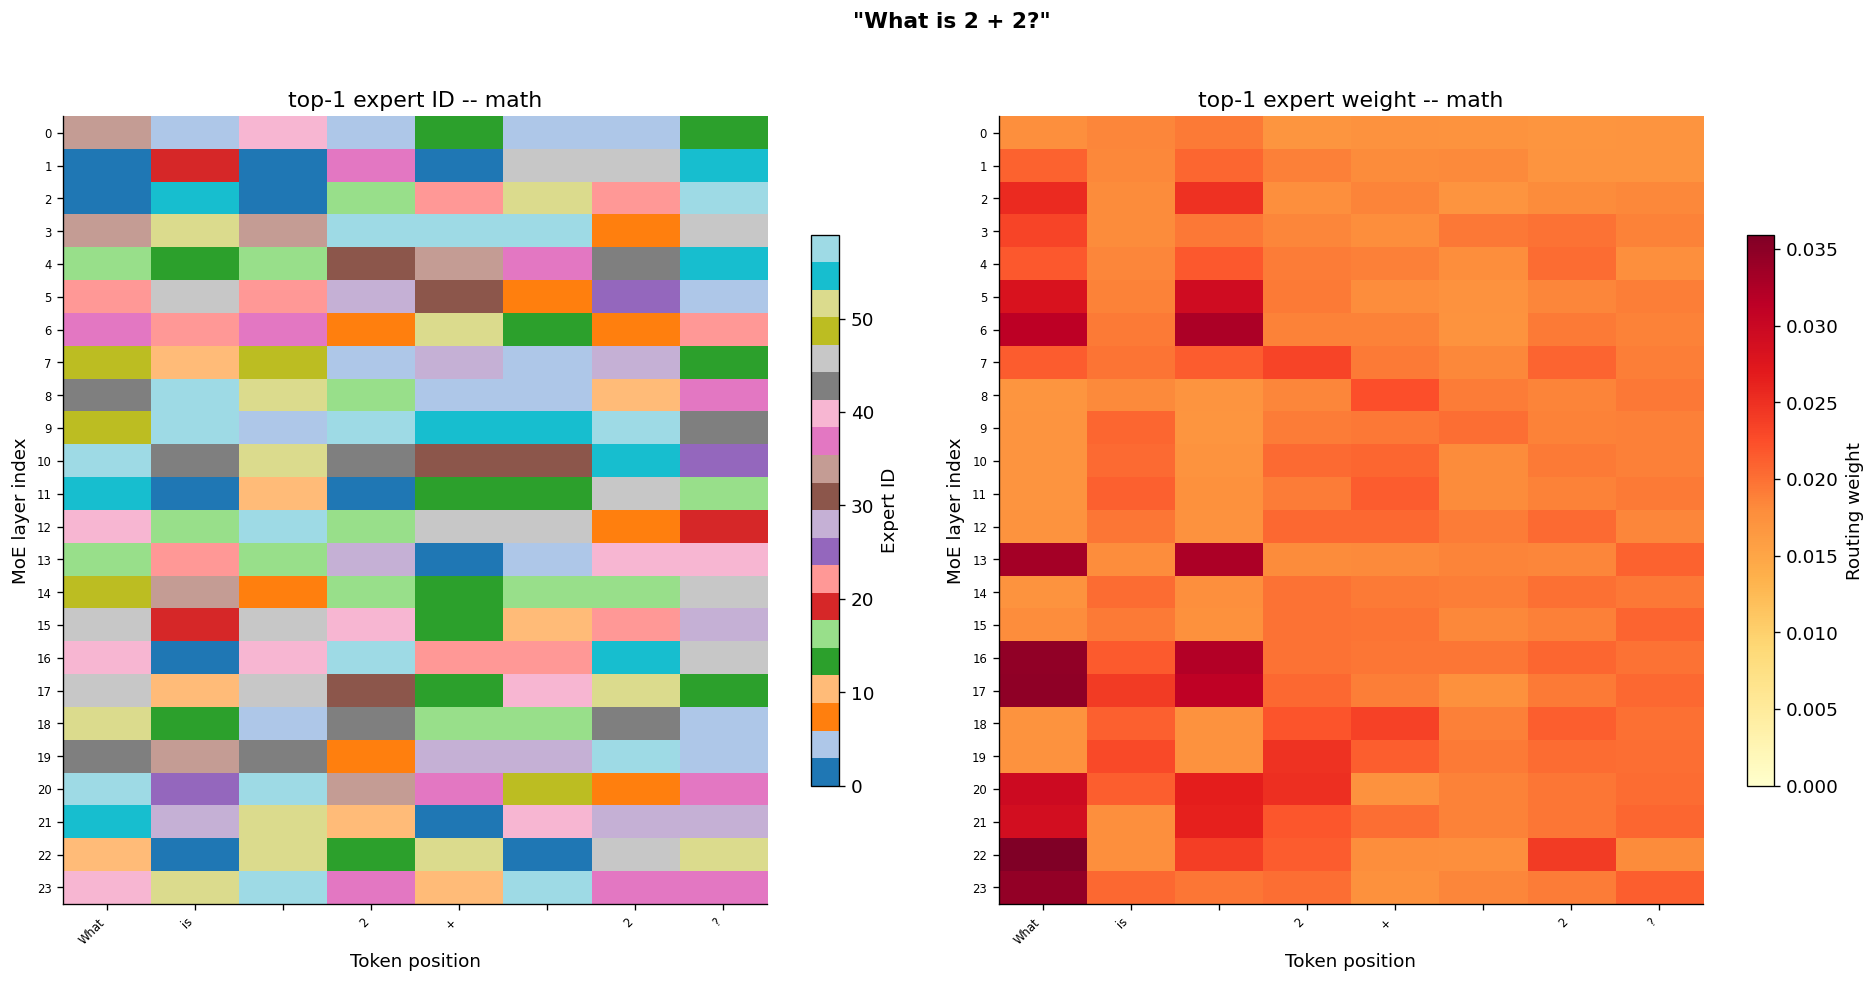

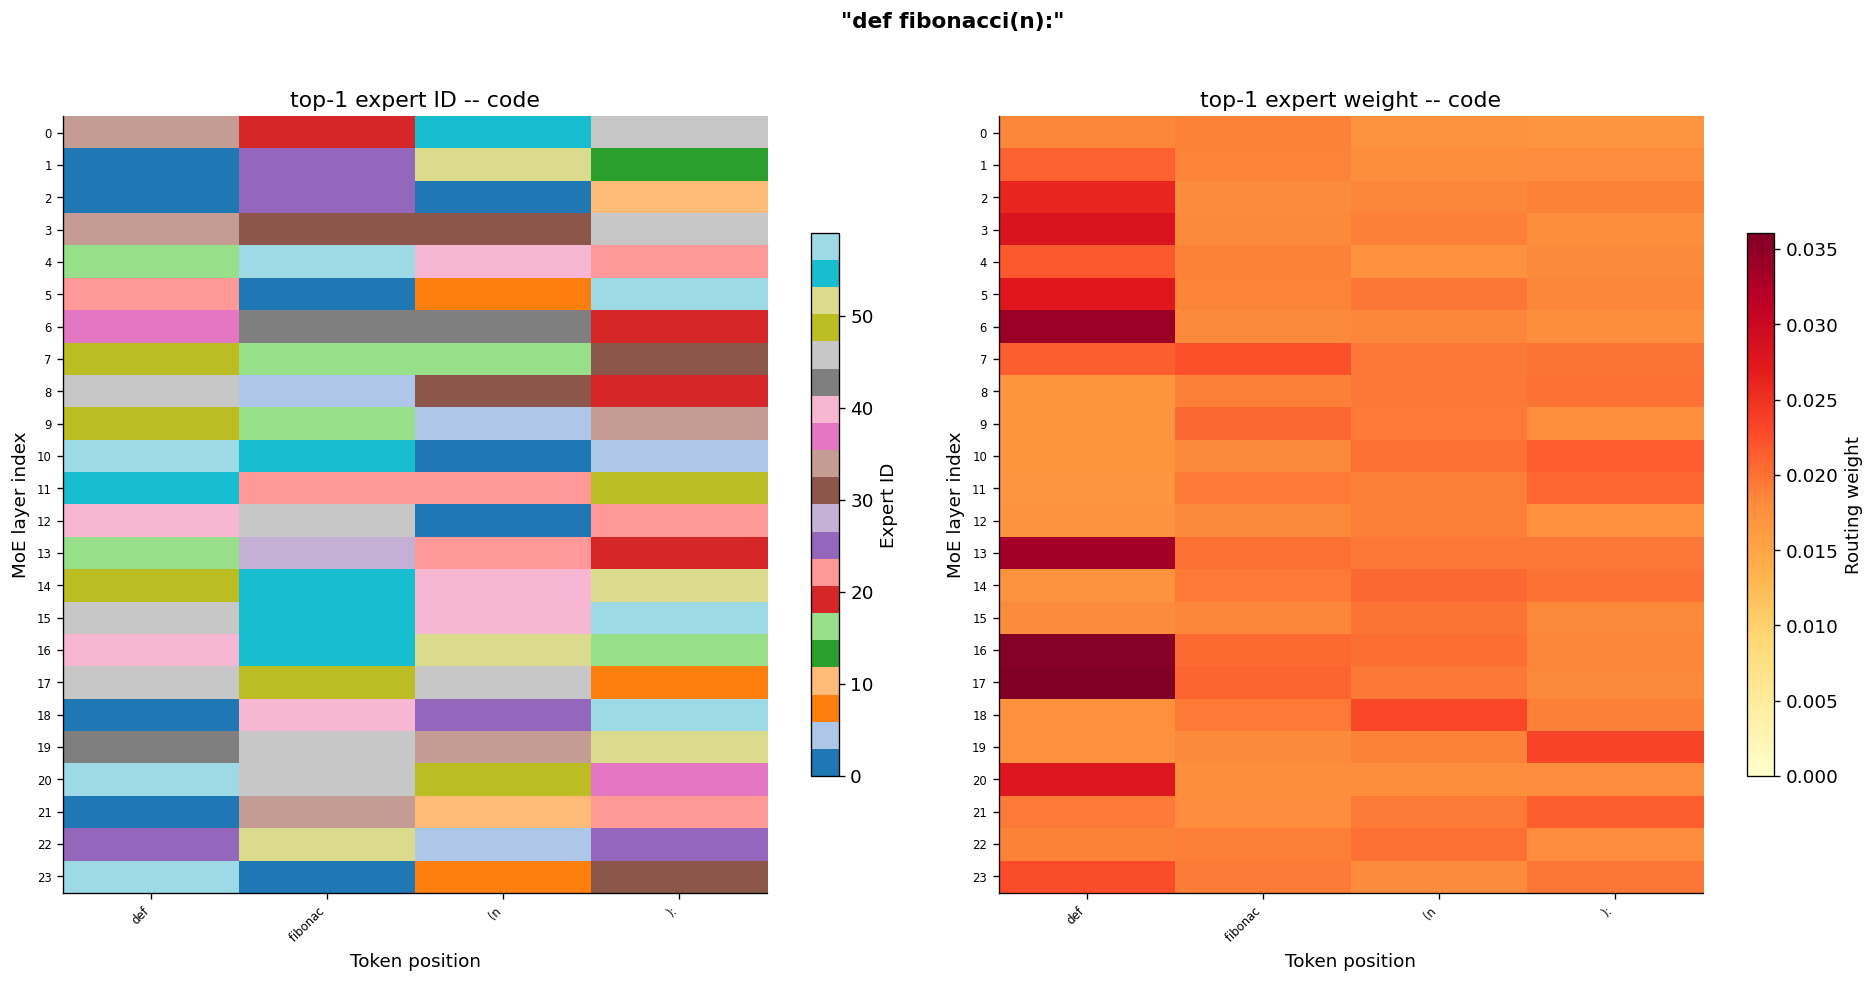

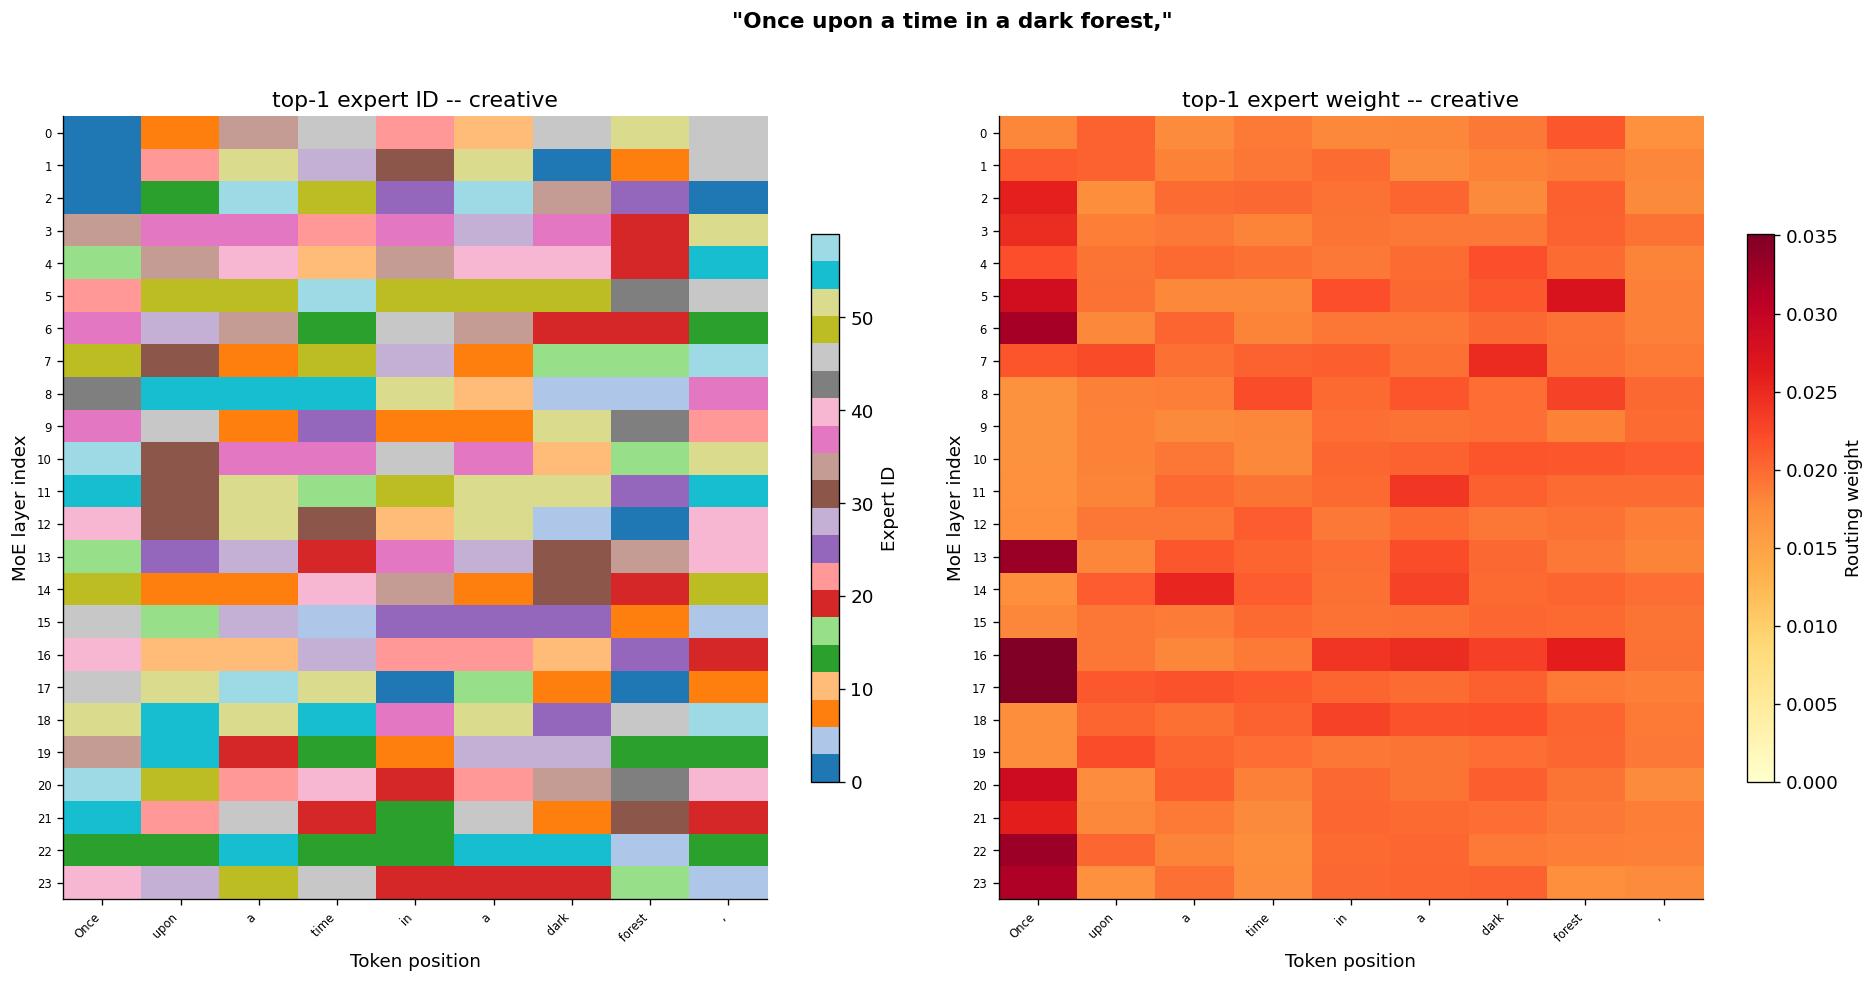

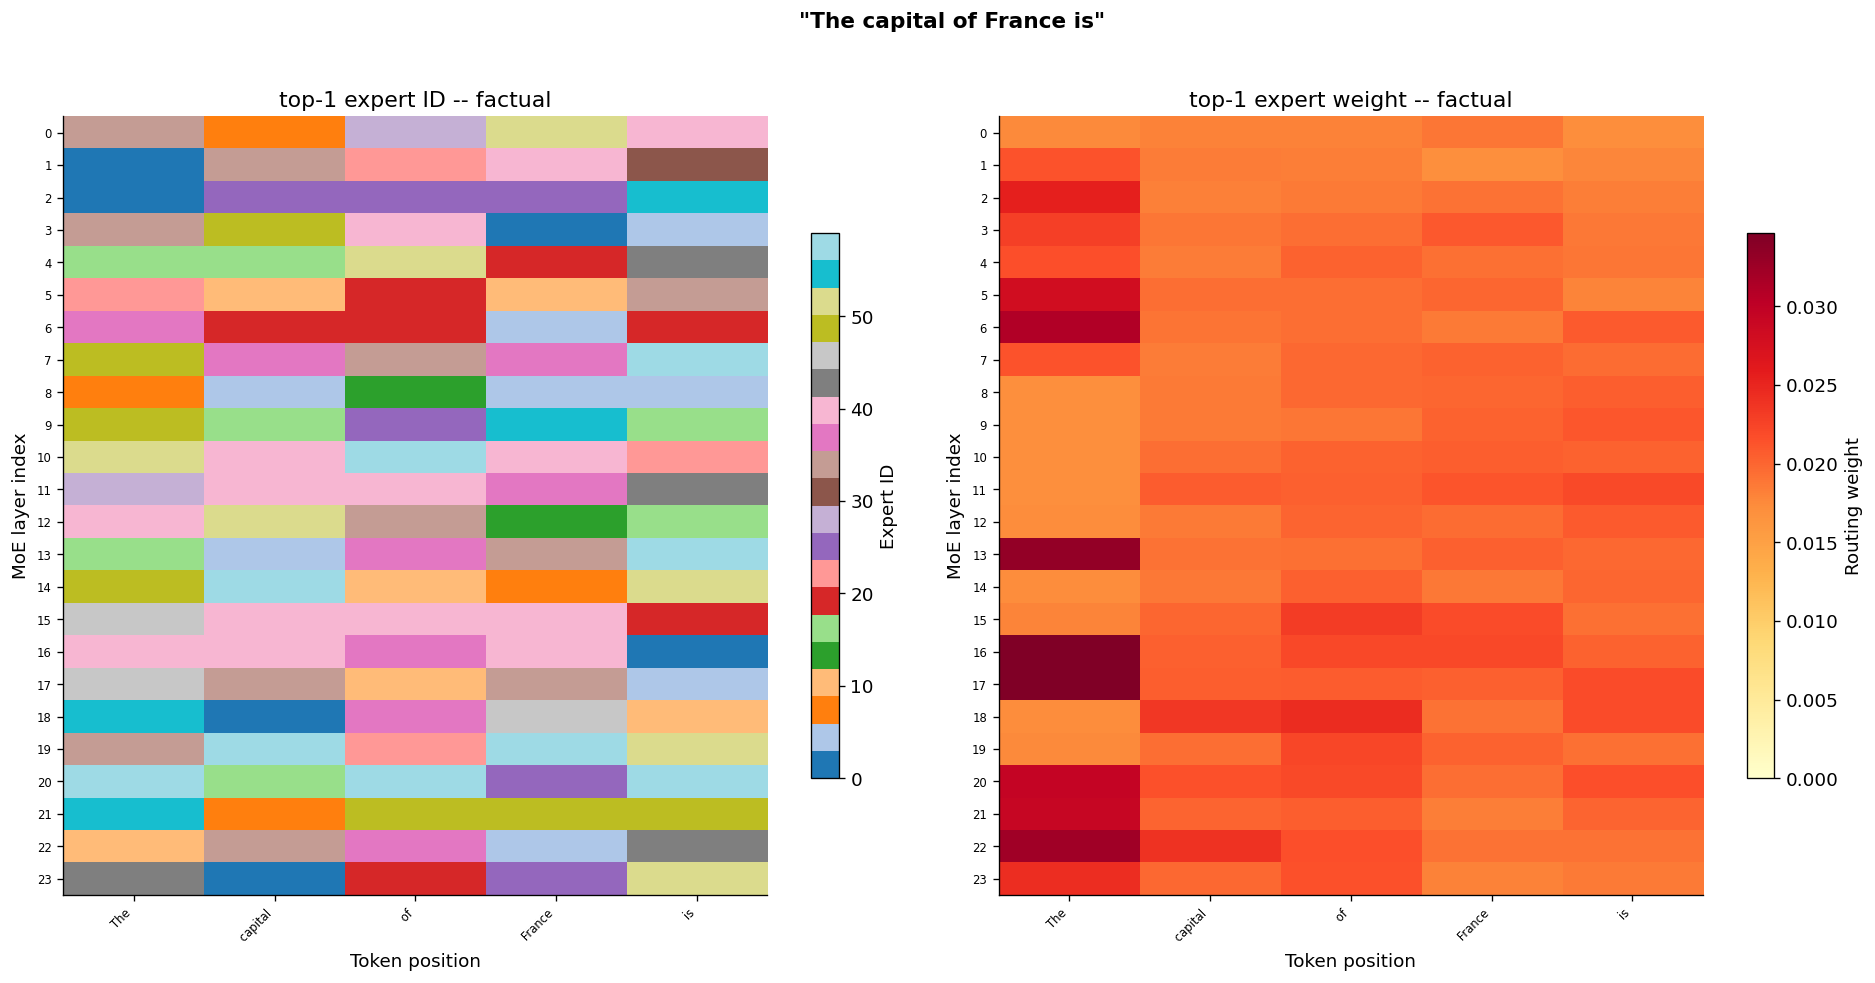

In [14]:
import numpy as np
# Plot top-1 expert heatmaps for all prompts
for prompt_name in prompts:
    plot_expert_heatmap(
        all_routing_data[prompt_name],
        all_tokens[prompt_name],
        prompt_name,
        top_k_slot=0,
    )

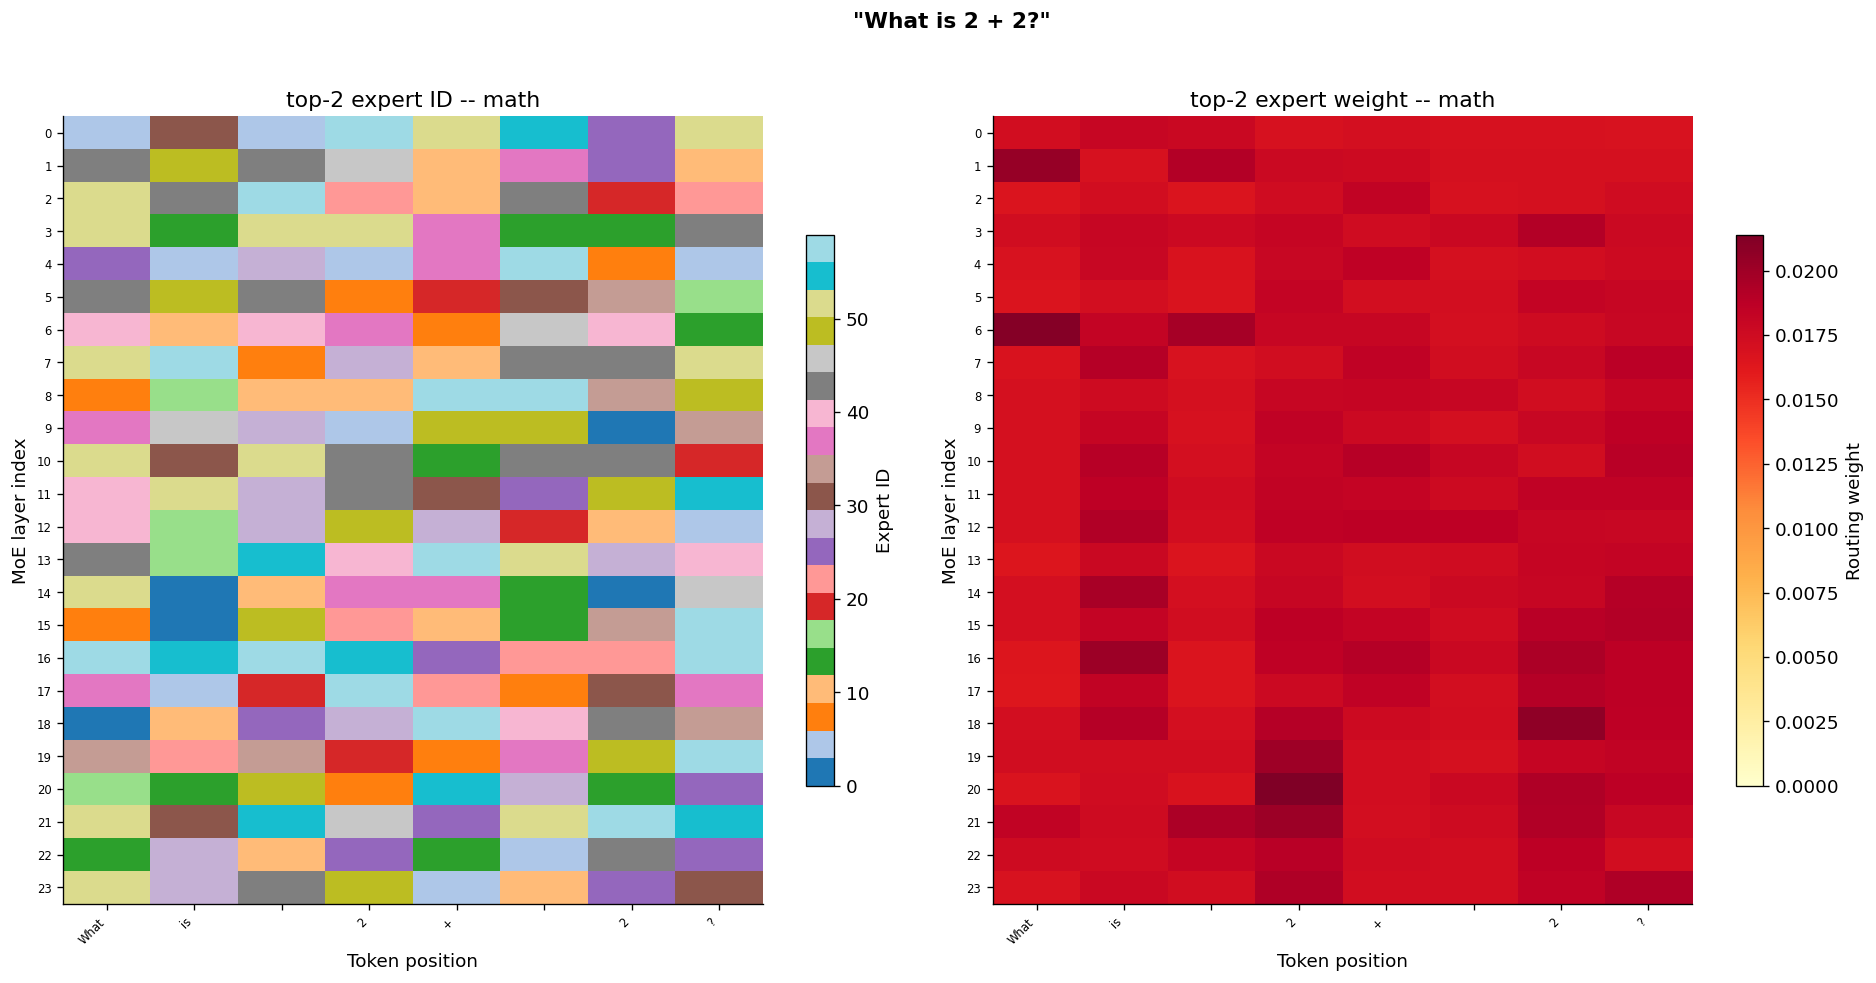

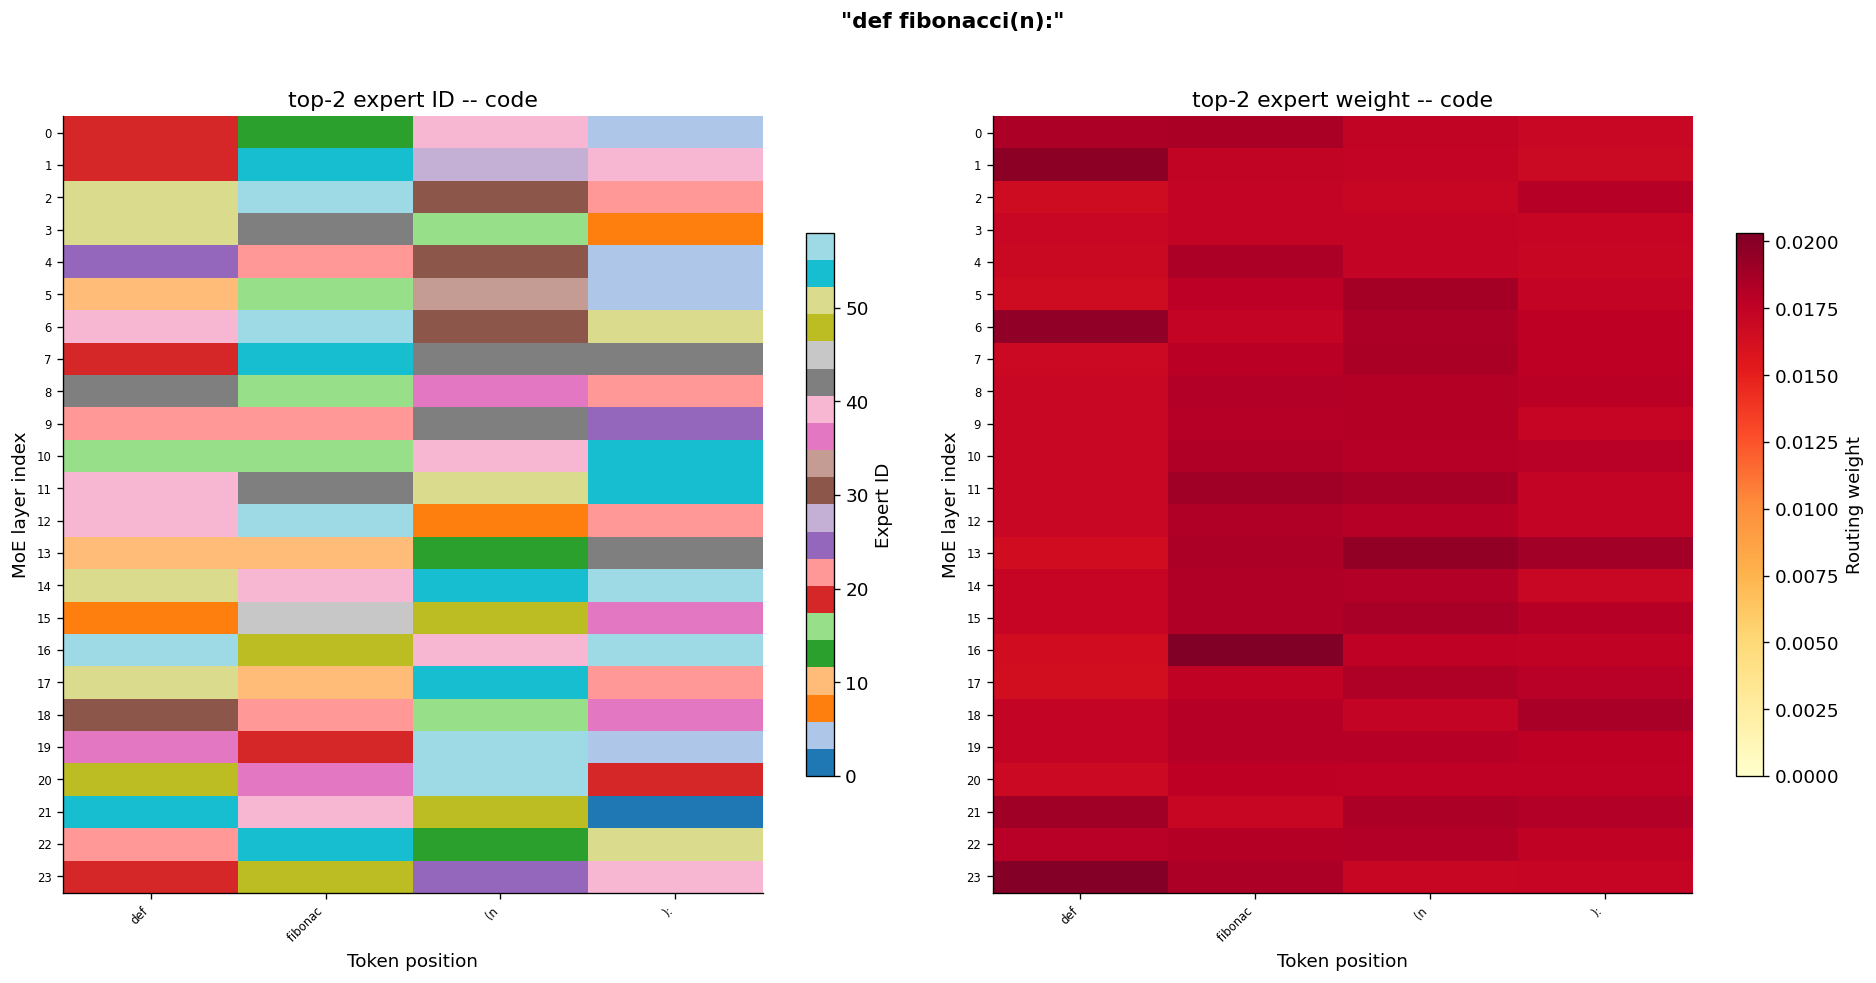

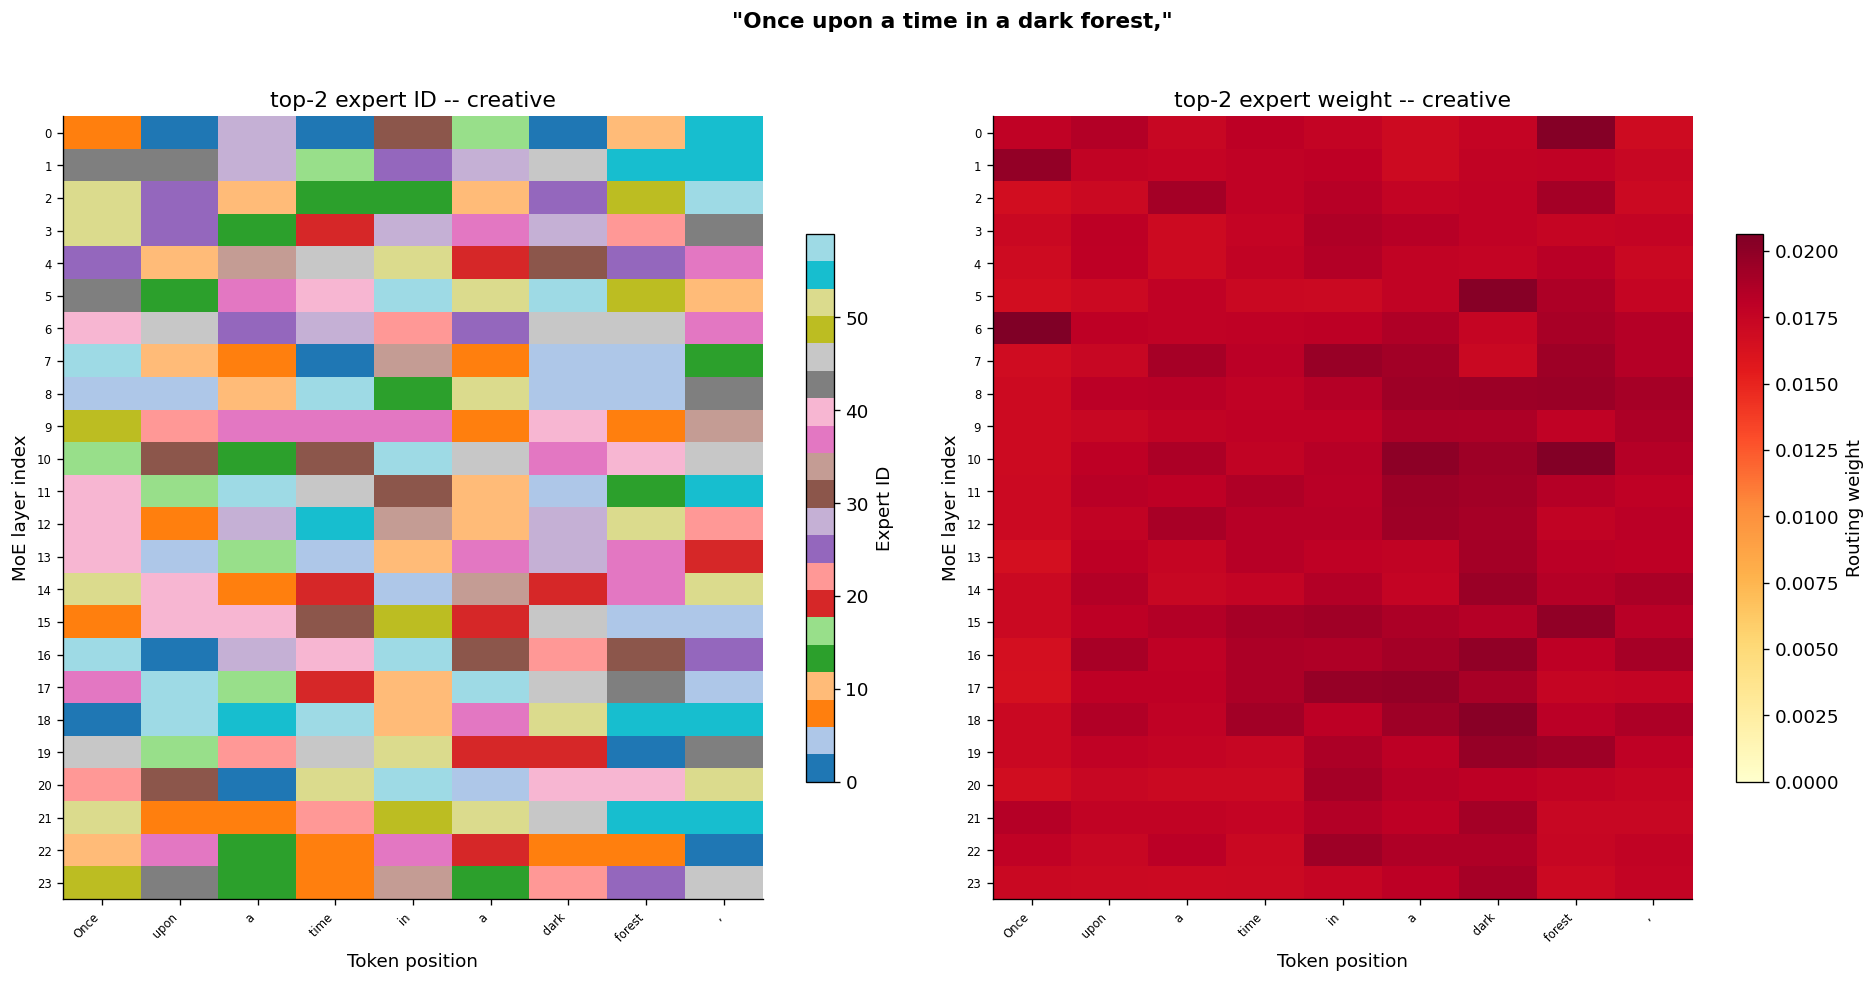

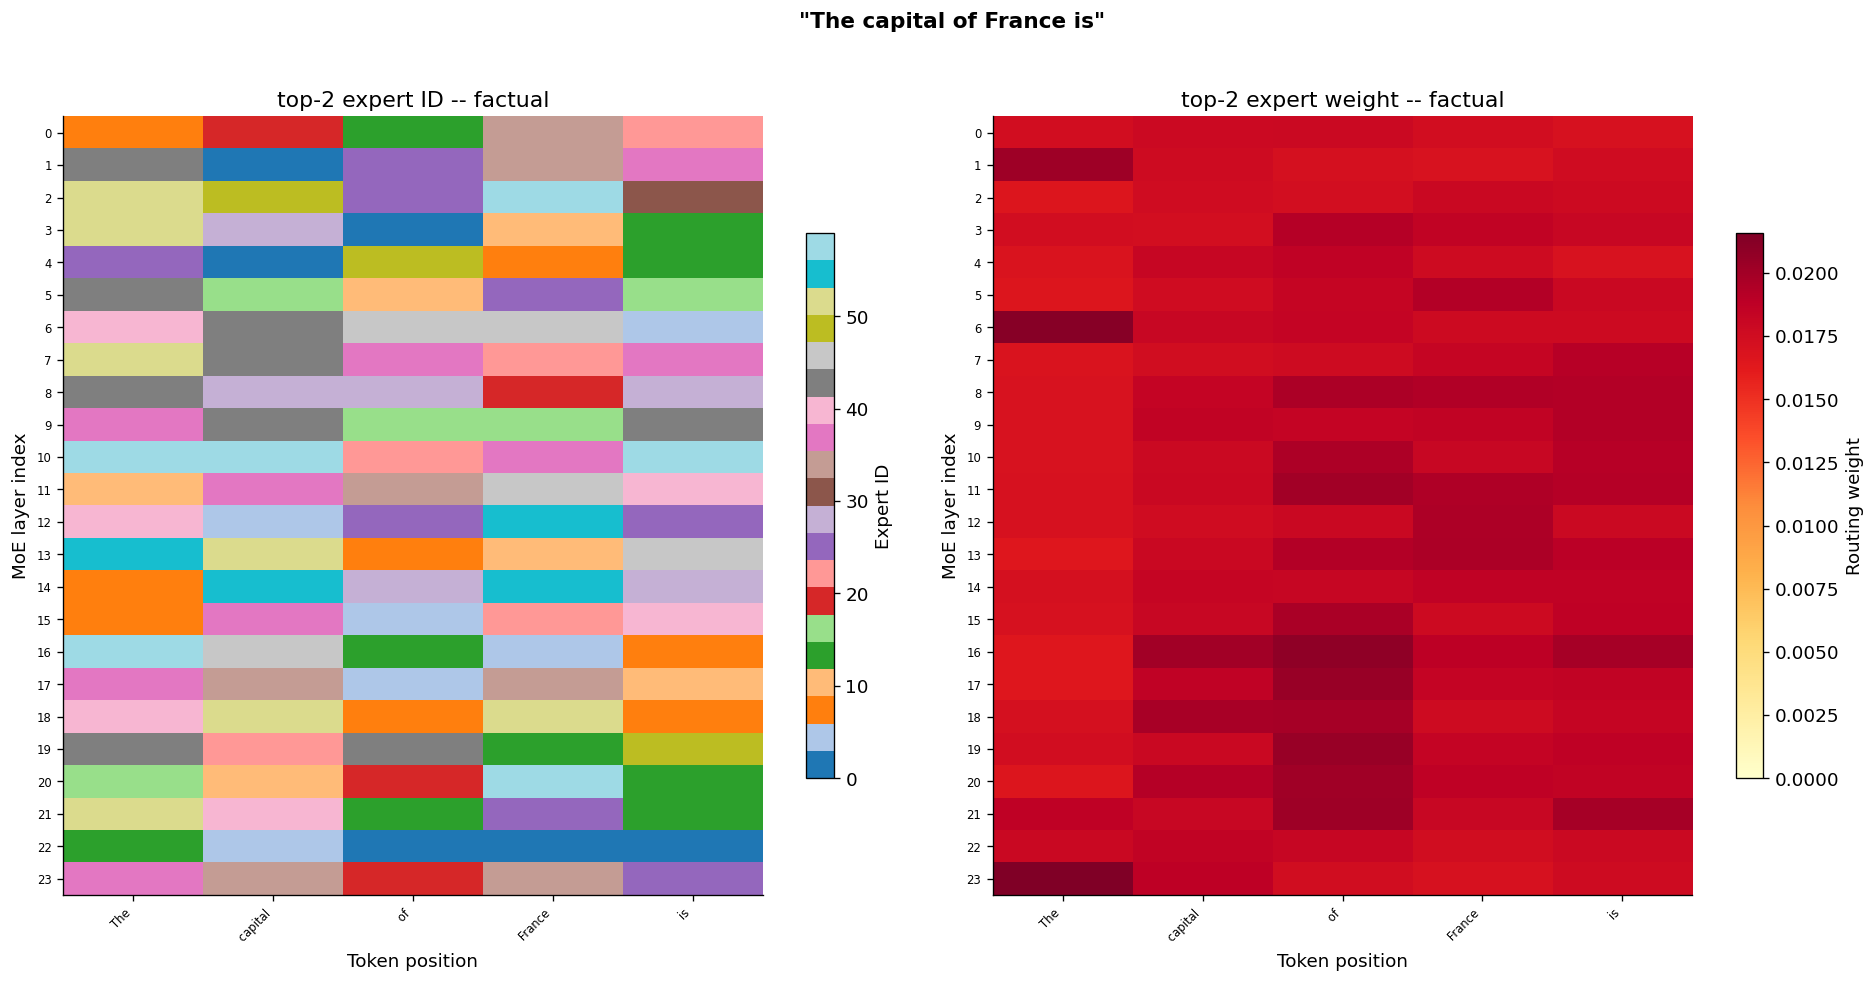

In [15]:
# Plot top-2 expert heatmaps for all prompts
for prompt_name in prompts:
    plot_expert_heatmap(
        all_routing_data[prompt_name],
        all_tokens[prompt_name],
        prompt_name,
        top_k_slot=1,
    )

---

## 6. Expert Utilization Across Prompts

We aggregate routing decisions across all prompts to see which experts are used
most frequently overall, and whether utilization varies by layer.

In [16]:
def compute_expert_utilization(all_routing_data, num_experts):
    """
    Count how many times each expert was selected across all prompts.
    Returns:
        overall_counts: (num_experts,) array
        per_layer_counts: dict mapping layer_idx -> (num_experts,) array
        per_prompt_counts: dict mapping prompt_name -> (num_experts,) array
    """
    overall_counts = np.zeros(num_experts)
    per_layer_counts = defaultdict(lambda: np.zeros(num_experts))
    per_prompt_counts = {}

    for prompt_name, routing_data in all_routing_data.items():
        prompt_counts = np.zeros(num_experts)
        for layer_idx, data in routing_data.items():
            # data["top_k_indices"]: (1, seq_len, top_k)
            indices = data["top_k_indices"][0].numpy().flatten()
            for eidx in indices:
                if eidx < num_experts:
                    overall_counts[eidx] += 1
                    per_layer_counts[layer_idx][eidx] += 1
                    prompt_counts[eidx] += 1
        per_prompt_counts[prompt_name] = prompt_counts

    return overall_counts, dict(per_layer_counts), per_prompt_counts


overall_counts, per_layer_counts, per_prompt_counts = compute_expert_utilization(
    all_routing_data, num_experts_total
)

print(f"Total expert selections across all prompts: {int(overall_counts.sum())}")
print(f"Number of unique experts used: {np.sum(overall_counts > 0)}")

Total expert selections across all prompts: 384
Number of unique experts used: 54


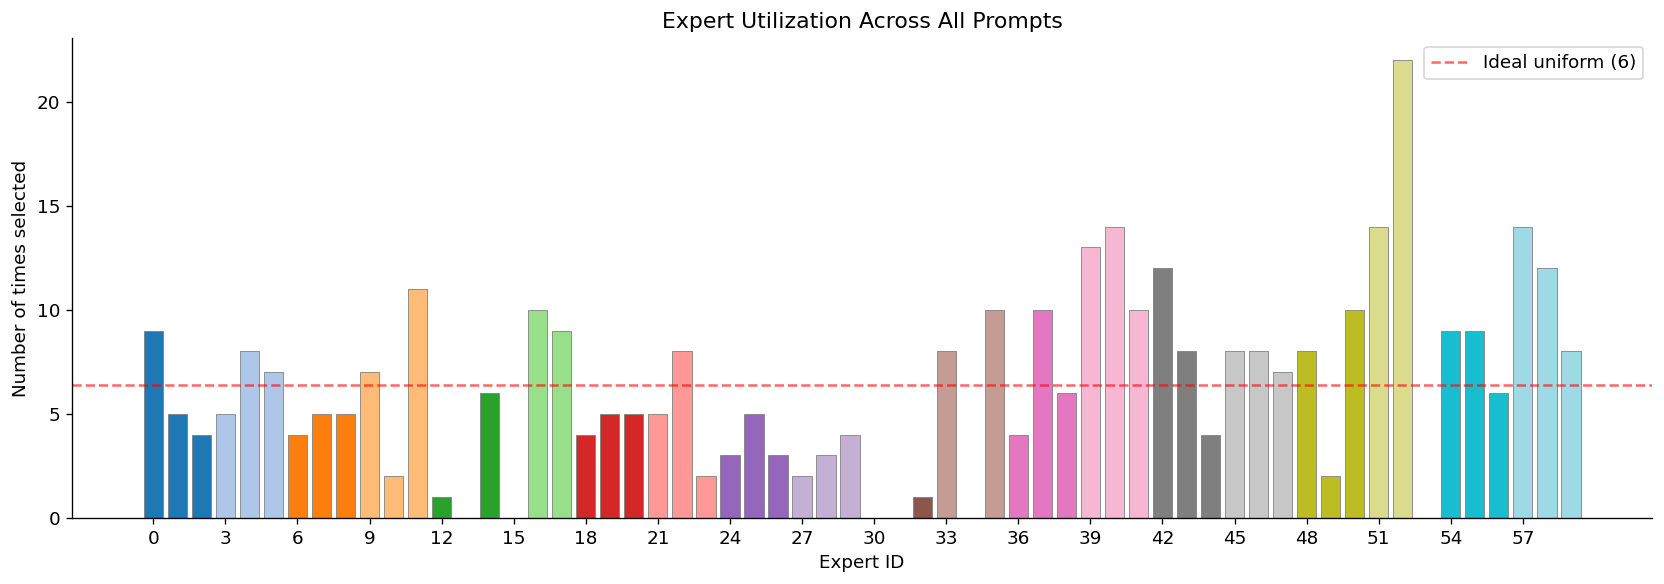

In [18]:
# Overall expert utilization bar chart
fig, ax = plt.subplots(figsize=(14, 5))

colors = plt.cm.tab20(np.linspace(0, 1, num_experts_total))
bars = ax.bar(range(num_experts_total), overall_counts, color=colors, edgecolor="gray",
              linewidth=0.5)

# Mark the ideal uniform level
ideal = overall_counts.sum() / num_experts_total
ax.axhline(y=ideal, color="red", linestyle="--", alpha=0.6,
           label=f"Ideal uniform ({ideal:.0f})")

ax.set_xlabel("Expert ID")
ax.set_ylabel("Number of times selected")
ax.set_title("Expert Utilization Across All Prompts")
ax.legend()

# Only show every Nth tick if too many experts
if num_experts_total > 20:
    tick_step = max(1, num_experts_total // 20)
    ax.set_xticks(range(0, num_experts_total, tick_step))
else:
    ax.set_xticks(range(num_experts_total))

plt.tight_layout()
plt.show()

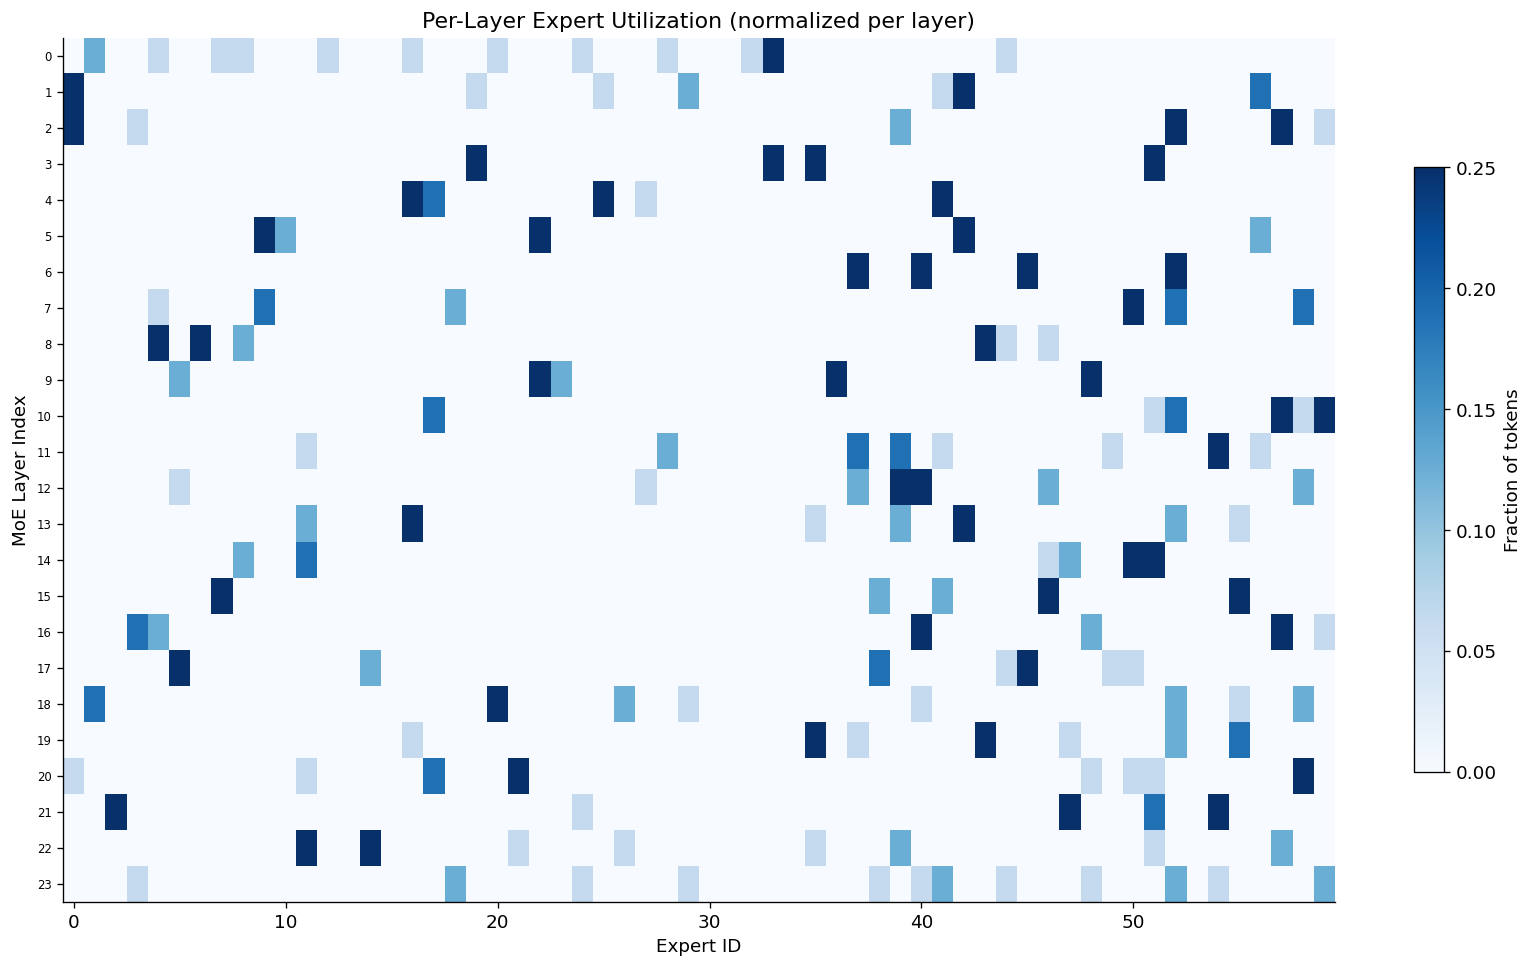

In [19]:
# Per-layer expert utilization heatmap
sorted_layers = sorted(per_layer_counts.keys())
num_layers_moe = len(sorted_layers)

# Sample layers if there are too many for a readable plot
if num_layers_moe > 20:
    step = max(1, num_layers_moe // 20)
    sampled_layers = sorted_layers[::step]
else:
    sampled_layers = sorted_layers

utilization_matrix = np.zeros((len(sampled_layers), num_experts_total))
for row, layer_idx in enumerate(sampled_layers):
    counts = per_layer_counts[layer_idx]
    total = counts.sum()
    if total > 0:
        utilization_matrix[row] = counts / total  # normalize per layer

fig, ax = plt.subplots(figsize=(14, max(4, len(sampled_layers) * 0.3 + 1)))
im = ax.imshow(utilization_matrix, aspect="auto", cmap="Blues", interpolation="nearest")
ax.set_xlabel("Expert ID")
ax.set_ylabel("MoE Layer Index")
ax.set_title("Per-Layer Expert Utilization (normalized per layer)")
ax.set_yticks(range(len(sampled_layers)))
ax.set_yticklabels(sampled_layers, fontsize=7)
if num_experts_total <= 20:
    ax.set_xticks(range(num_experts_total))
plt.colorbar(im, ax=ax, label="Fraction of tokens", shrink=0.7)
plt.tight_layout()
plt.show()

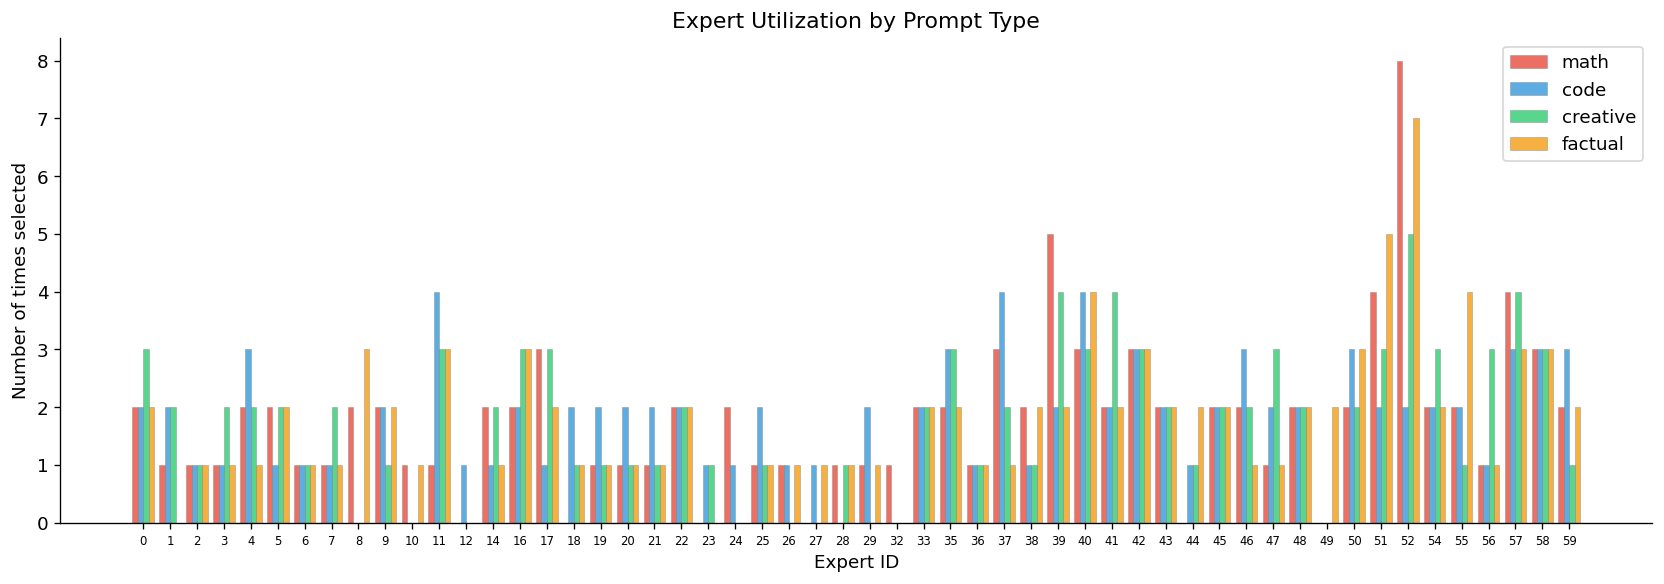

In [20]:
# Per-prompt expert utilization comparison
fig, ax = plt.subplots(figsize=(14, 5))

prompt_names = list(per_prompt_counts.keys())
num_prompts = len(prompt_names)
bar_width = 0.8 / num_prompts
prompt_colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

# Only show experts that were actually used
used_experts = np.where(overall_counts > 0)[0]
x_positions = np.arange(len(used_experts))

for pidx, pname in enumerate(prompt_names):
    counts = per_prompt_counts[pname][used_experts]
    offset = (pidx - num_prompts / 2 + 0.5) * bar_width
    ax.bar(x_positions + offset, counts, bar_width, label=pname,
           color=prompt_colors[pidx % len(prompt_colors)], alpha=0.8,
           edgecolor="gray", linewidth=0.3)

ax.set_xlabel("Expert ID")
ax.set_ylabel("Number of times selected")
ax.set_title("Expert Utilization by Prompt Type")
ax.set_xticks(x_positions)
ax.set_xticklabels(used_experts, fontsize=7)
ax.legend()
plt.tight_layout()
plt.show()

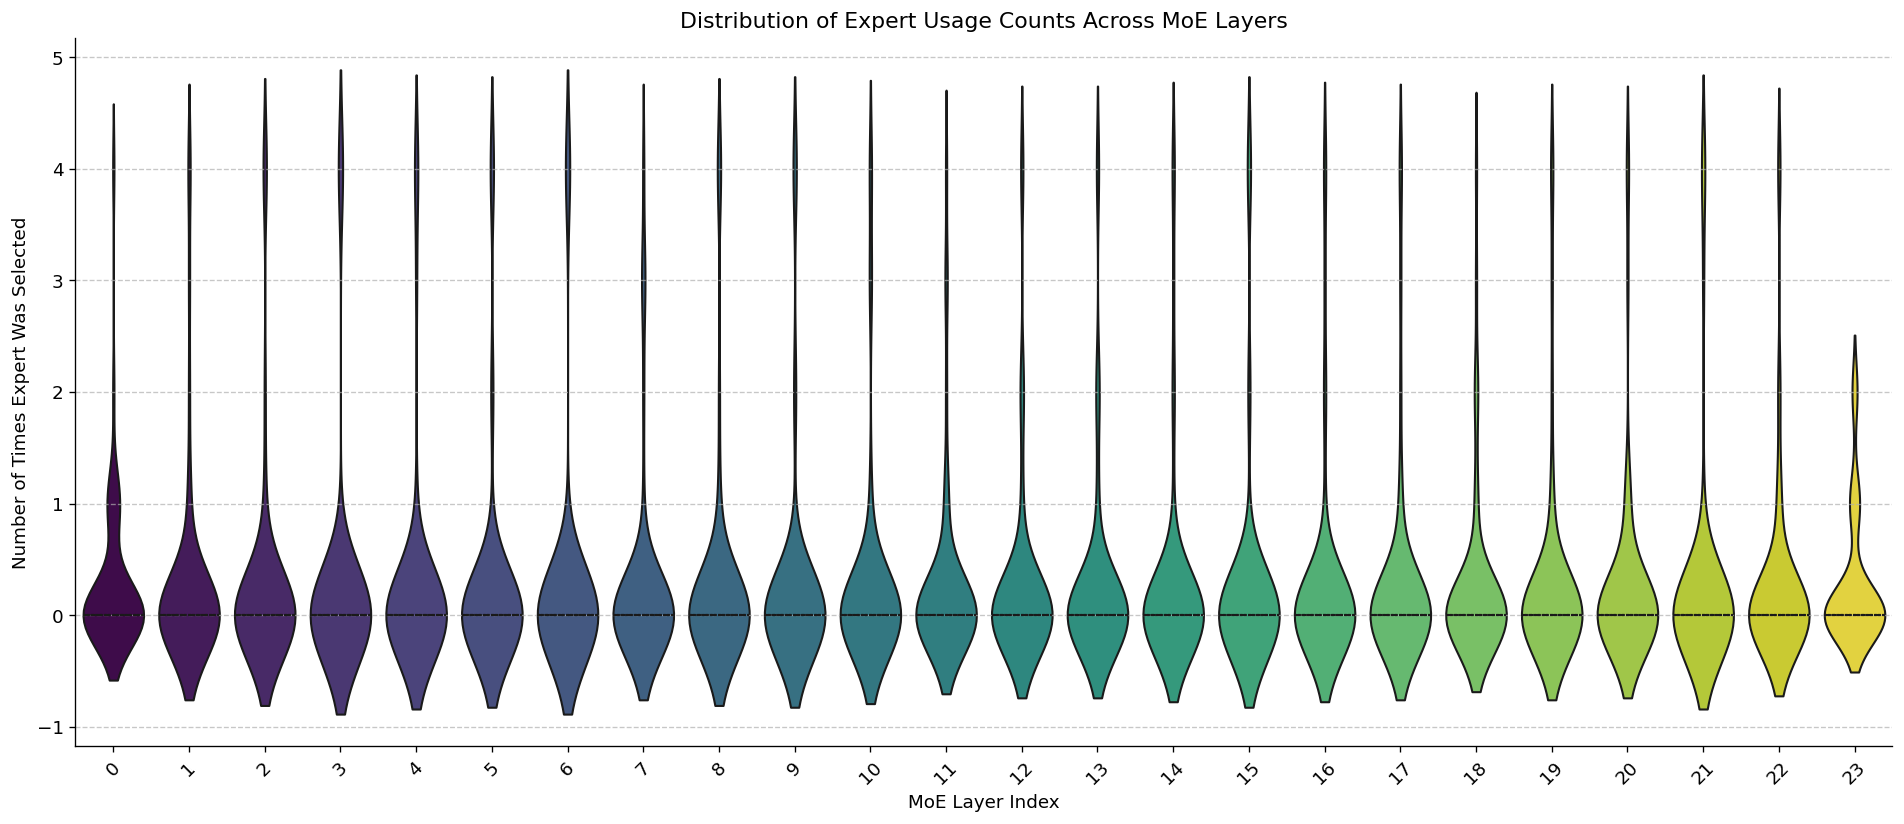

In [64]:
import pandas as pd

# Prepare data for plotting the distribution of expert usage counts per layer
expert_usage_data = []
for layer_idx, counts_array in per_layer_counts.items():
    for expert_id, count in enumerate(counts_array):
        expert_usage_data.append({
            'Layer': layer_idx,
            'ExpertID': expert_id,
            'UsageCount': count
        })

df_expert_usage = pd.DataFrame(expert_usage_data)

# Plotting the distribution of expert usage counts per layer using violin plot
plt.figure(figsize=(16, 7))
sns.violinplot(x='Layer', y='UsageCount', data=df_expert_usage, inner='quartile', palette='viridis', hue='Layer', legend=False)
plt.title('Distribution of Expert Usage Counts Across MoE Layers')
plt.xlabel('MoE Layer Index')
plt.ylabel('Number of Times Expert Was Selected')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The violin plot showing the distribution of expert usage counts across MoE layers provides several insights:

*   **Central Tendency**: The white dot in the middle of each violin represents the median usage count for experts in that layer.
*   **Interquartile Range**: The thick black bar in the center of each violin shows the interquartile range (IQR), representing the middle 50% of the data.
*   **Range**: The thin black lines extending from the IQR indicate the rest of the distribution, excluding outliers.
*   **Density**: The shape of the violin itself represents the kernel density estimation of the data, showing where the majority of expert usage counts fall. A wider section indicates a higher concentration of experts with that specific usage count.

From this plot, we can observe patterns such as whether certain layers have a more concentrated or spread-out distribution of expert usage, indicating potentially different routing behaviors or specialization levels across the network's depth. It seems that for many layers, there's a significant concentration of experts that are rarely or never used, while a few experts are used more frequently.

---

## 7. Token-Level Expert Routing

For a single prompt, we create a detailed view that maps each token to its
selected experts at every MoE layer. This reveals patterns in how the model
routes different types of tokens (punctuation, nouns, verbs, numbers, etc.).

In [23]:
def plot_token_routing_detail(routing_data, tokens, prompt_name, max_layers=12):
    """
    Show a detailed annotated heatmap of expert routing for a single prompt.
    Each cell shows the top-1 expert ID, colored by expert identity.
    """
    layer_indices = sorted(routing_data.keys())
    if len(layer_indices) > max_layers:
        # Sample evenly
        step = max(1, len(layer_indices) // max_layers)
        layer_indices = layer_indices[::step][:max_layers]

    num_layers = len(layer_indices)
    num_tokens = len(tokens)

    # Build the annotation matrix
    expert_matrix = np.zeros((num_layers, num_tokens), dtype=int)
    annotation_matrix = []

    for row, layer_idx in enumerate(layer_indices):
        data = routing_data[layer_idx]
        row_annotations = []
        for tok in range(num_tokens):
            top1 = data["top_k_indices"][tok, 0].item()
            top1_w = data["top_k_weights"][tok, 0].item()
            expert_matrix[row, tok] = top1
            if top_k > 1:
                top2 = data["top_k_indices"][tok, 1].item()
                row_annotations.append(f"{top1}\n({top2})")
            else:
                row_annotations.append(str(top1))
        annotation_matrix.append(row_annotations)

    fig, ax = plt.subplots(figsize=(max(10, num_tokens * 1.0),
                                     max(4, num_layers * 0.5 + 1)))

    im = ax.imshow(expert_matrix, aspect="auto", cmap="tab20",
                    interpolation="nearest")

    # Annotate each cell
    for row in range(num_layers):
        for col in range(num_tokens):
            ax.text(col, row, annotation_matrix[row][col],
                    ha="center", va="center", fontsize=6,
                    color="white", fontweight="bold")

    ax.set_xlabel("Token")
    ax.set_ylabel("MoE Layer")
    ax.set_title(f"Token-Level Expert Routing -- {prompt_name}\n"
                 f"(cell = top-1 expert, parentheses = top-2 expert)")
    ax.set_xticks(range(num_tokens))
    truncated = [t.replace("\n", "\\n")[:10] for t in tokens]
    ax.set_xticklabels(truncated, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(num_layers))
    ax.set_yticklabels([f"L{idx}" for idx in layer_indices], fontsize=8)
    plt.colorbar(im, ax=ax, label="Expert ID", shrink=0.7)

    plt.tight_layout()
    plt.show()

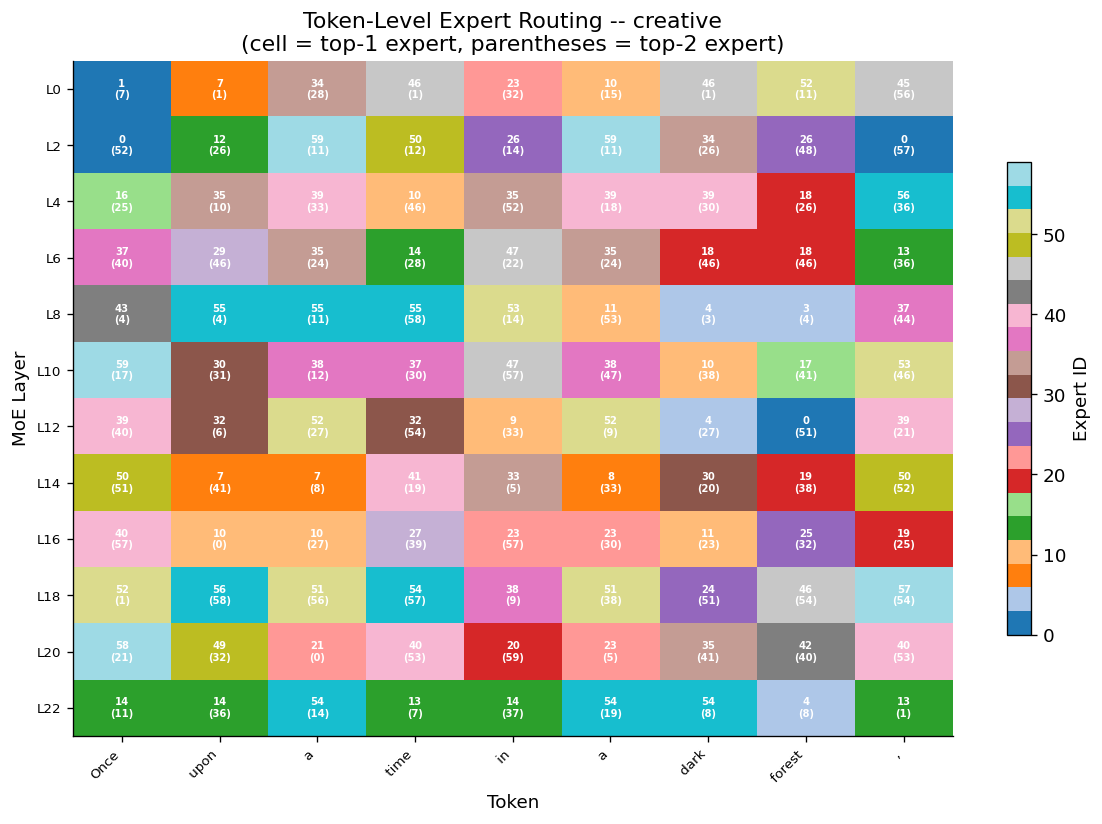

In [24]:
# Detailed token-level routing for the creative prompt
plot_token_routing_detail(
    all_routing_data["creative"],
    all_tokens["creative"],
    "creative",
)

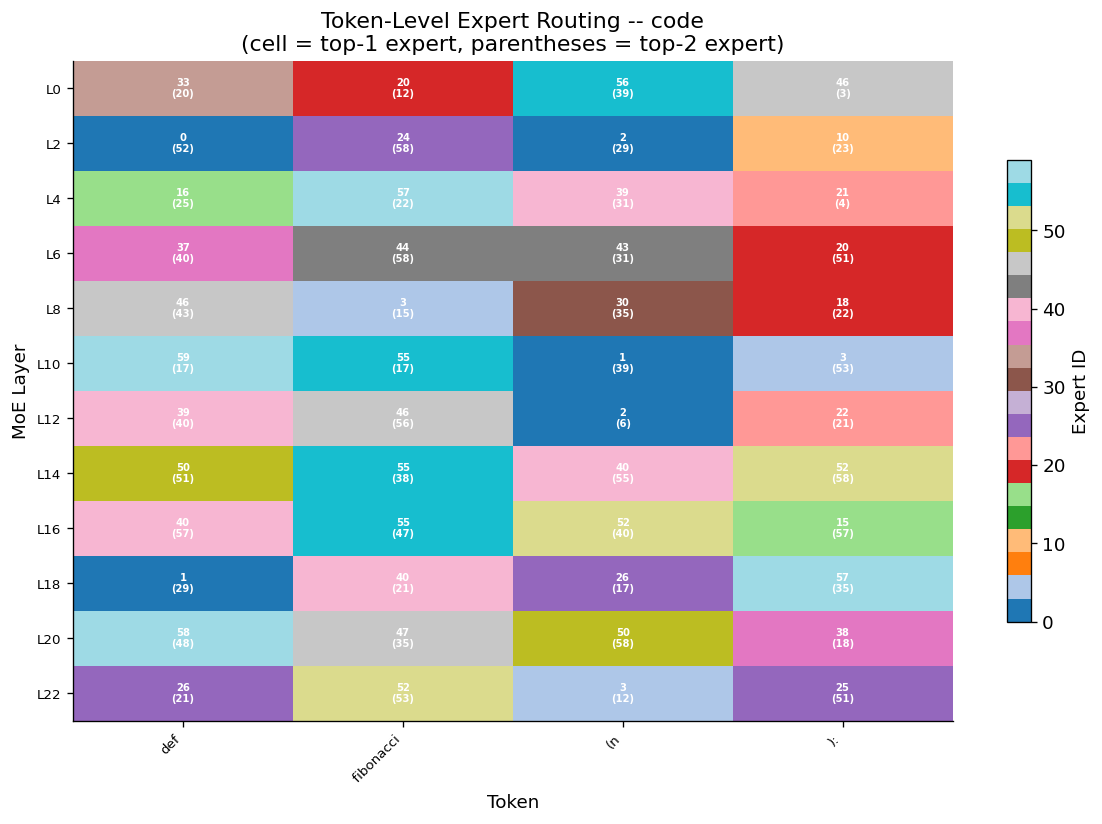

In [25]:
# Detailed token-level routing for the code prompt
plot_token_routing_detail(
    all_routing_data["code"],
    all_tokens["code"],
    "code",
)

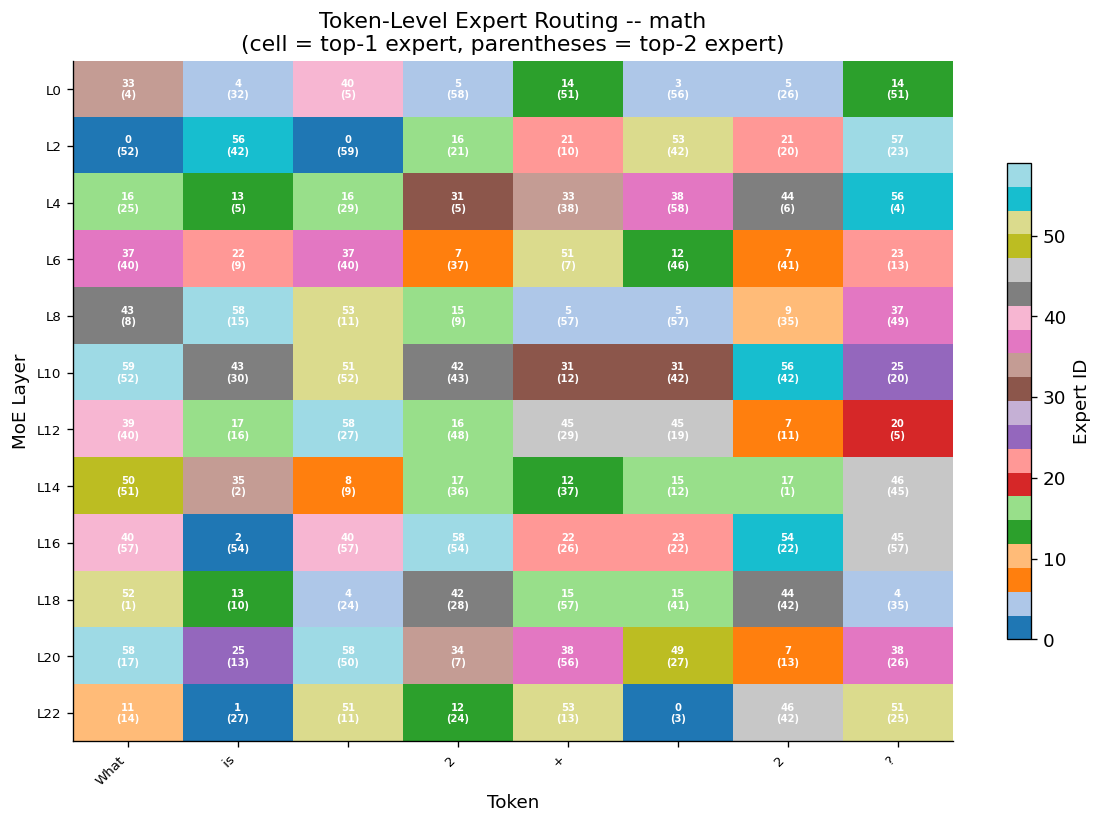

In [26]:
# Detailed token-level routing for the math prompt
plot_token_routing_detail(
    all_routing_data["math"],
    all_tokens["math"],
    "math",
)

---    
## 10.3 Targeted Test for Expert 52

Given that Expert ID 52 was identified as the most frequently used, let's create a targeted prompt to see its activation patterns. We will use a general English sentence, hypothesizing that Expert 52 might be involved in core linguistic processing.

In [66]:
test_prompt_name = "expert_52_test"
test_prompt_text = "This sentence is designed to engage a wide variety of linguistic processing modules within the model, exploring its general language understanding capabilities."

print(f"\nProcessing [{test_prompt_name}]: \"{test_prompt_text}\"")

# Prepare inputs
inputs = tokenizer(test_prompt_text, return_tensors="pt").to(model.device)
input_token_ids = inputs["input_ids"][0].tolist()
token_strings_for_model_input = [tokenizer.decode([tid]) for tid in input_token_ids]

# Clear previous capture and run inference for the new prompt
capture.clear()
with torch.no_grad():
    outputs = model(**inputs)

# Store routing data for the new prompt
expert_52_routing_data = capture.get_routing_data()
expert_52_tokens = token_strings_for_model_input

# Add this new prompt's data to the collective dictionaries for potential future analysis
# (Note: This will overwrite previous data if run multiple times without clearing overall dictionaries first)
all_routing_data[test_prompt_name] = expert_52_routing_data
all_tokens[test_prompt_name] = expert_52_tokens
prompts[test_prompt_name] = test_prompt_text # Add to original prompts dict for consistent plotting titles


Processing [expert_52_test]: "This sentence is designed to engage a wide variety of linguistic processing modules within the model, exploring its general language understanding capabilities."


### Expert Activation Heatmap for Expert 52 Test Prompt

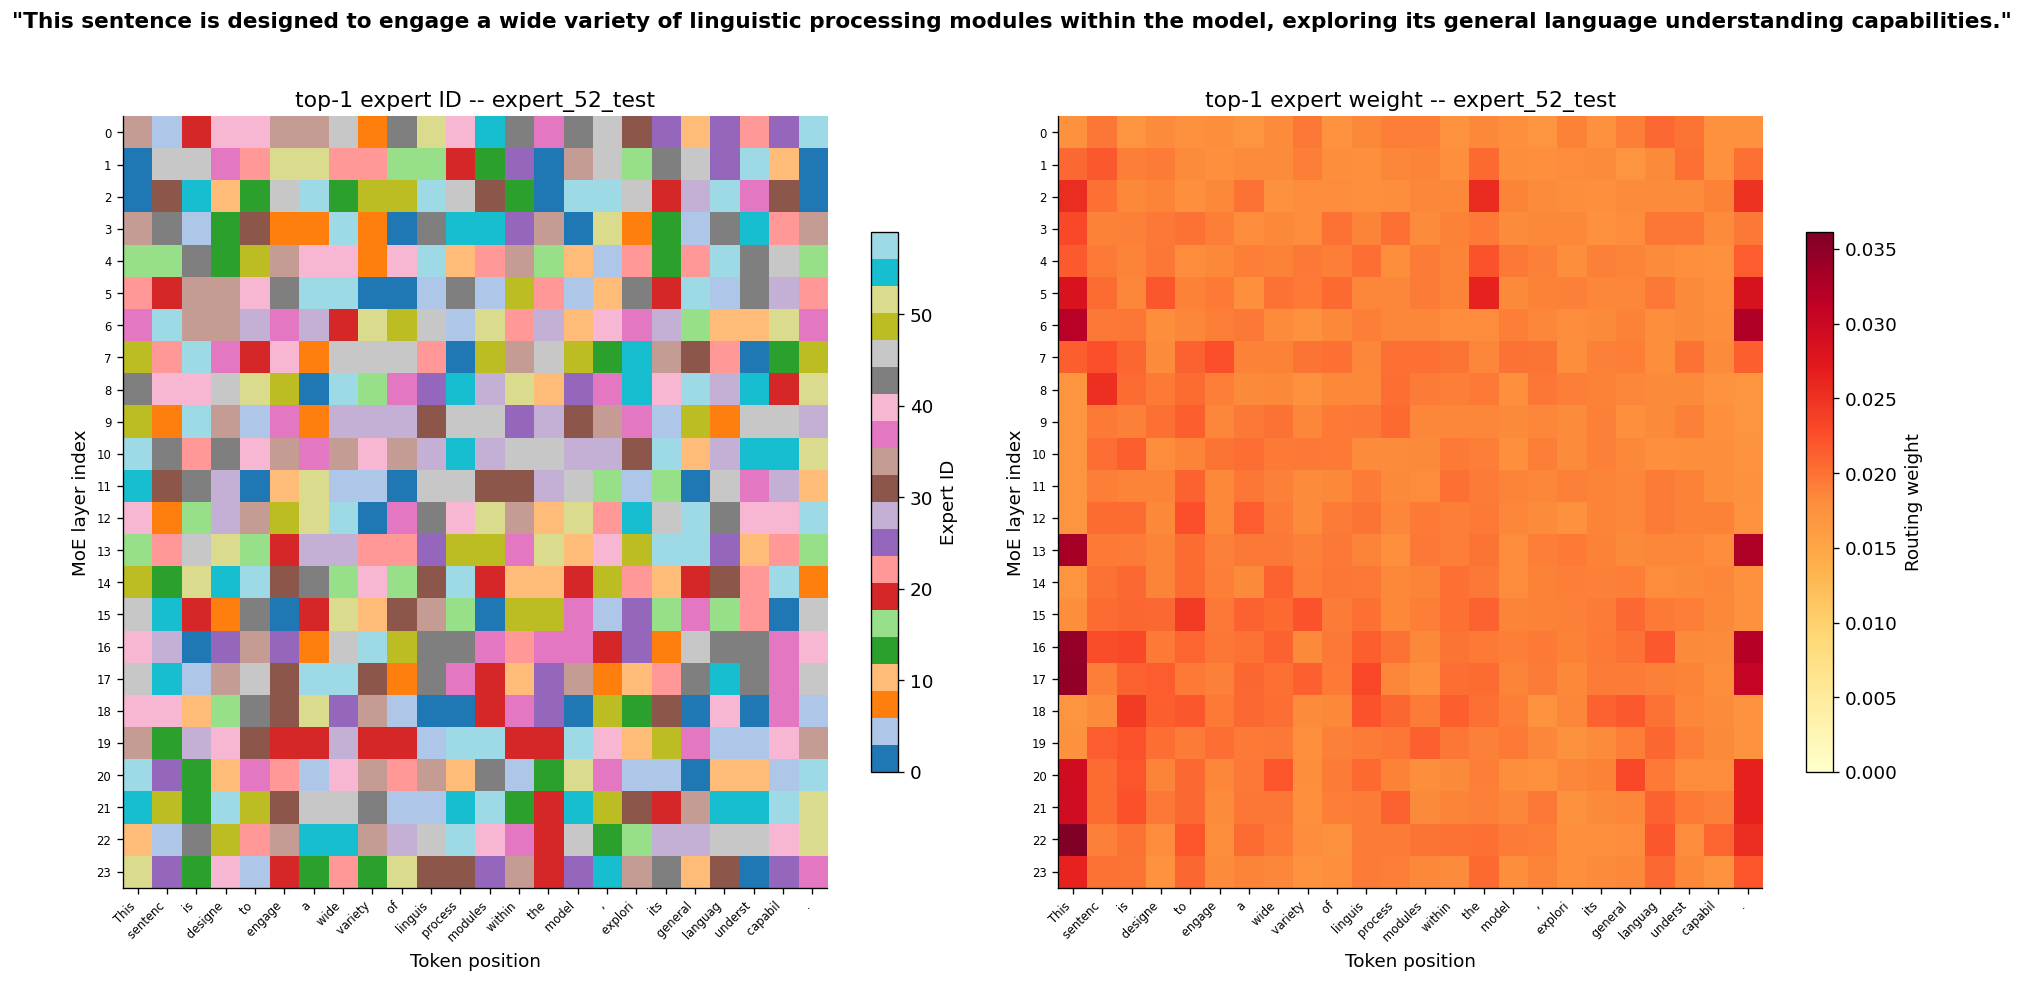

In [67]:
# Plot top-1 expert heatmap for the new test prompt
plot_expert_heatmap(
    expert_52_routing_data,
    expert_52_tokens,
    test_prompt_name,
    top_k_slot=0,
)

### Token-Level Expert Routing Detail for Expert 52 Test Prompt

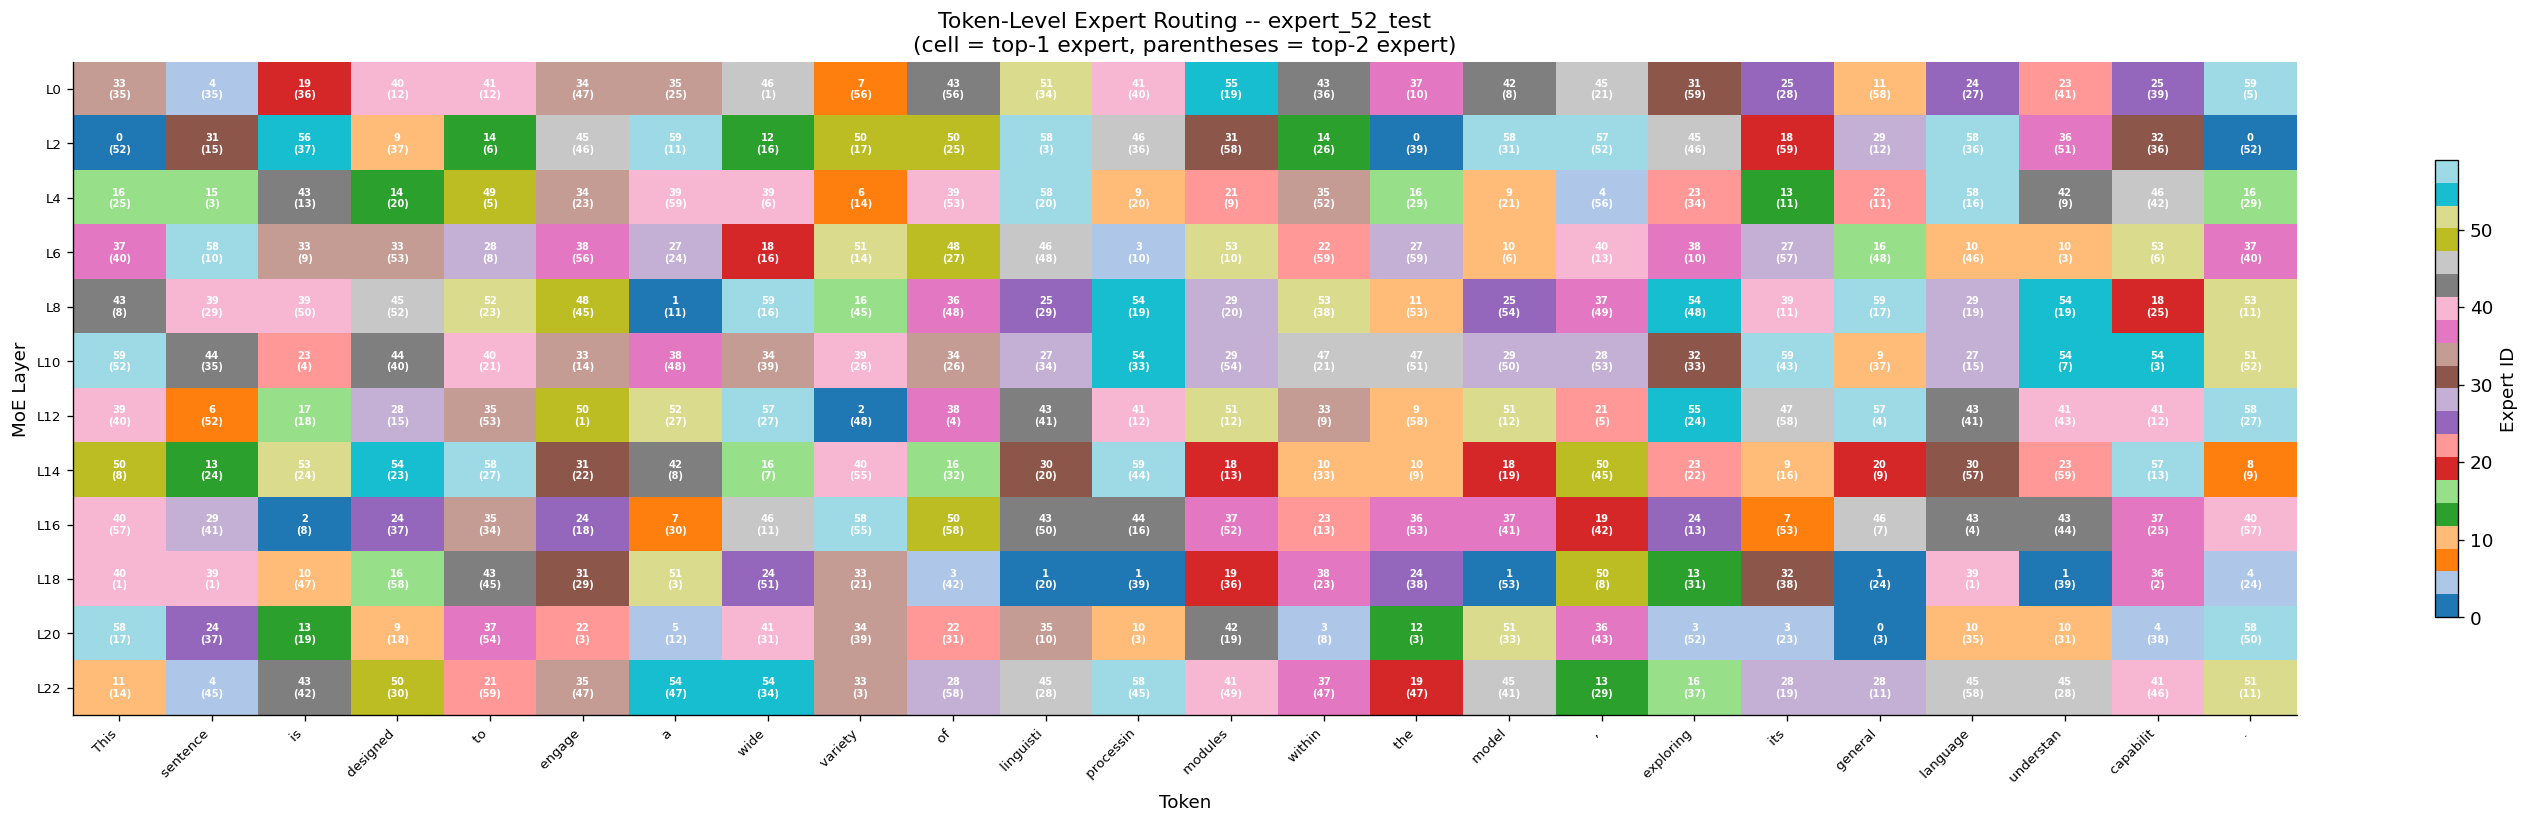

In [68]:
# Detailed token-level routing for the new test prompt
plot_token_routing_detail(
    expert_52_routing_data,
    expert_52_tokens,
    test_prompt_name,
)

---

## 8. Expert Similarity Analysis

We compare router decisions between different prompts to understand whether
different input types activate systematically different sets of experts.
We compute cosine similarity between the average router probability vectors
across prompts.

In [31]:
def compute_avg_routing_profile(routing_data, num_experts):
    """
    Compute the average router probability vector across all layers and tokens
    for a single prompt. Returns a (num_experts,) vector.
    """
    all_probs = []
    for layer_idx, data in routing_data.items():
        # data["probs"]: (seq_len, num_experts)
        probs = data["probs"].numpy()  # Get (seq_len, num_experts) array for the layer
        all_probs.append(probs)
    # Stack all (token) probability vectors into a single 2D array (total_tokens, num_experts)
    stacked = np.concatenate(all_probs, axis=0)  # (total_tokens, num_experts)
    return stacked.mean(axis=0)  # (num_experts,)

In [33]:
# Compute average routing profiles for each prompt
prompt_names = list(prompts.keys())
profiles = {}
for pname in prompt_names:
    profiles[pname] = compute_avg_routing_profile(
        all_routing_data[pname], num_experts_total
    )
    print(f"{pname:>12}: top-3 experts by avg probability: "
          f"{np.argsort(profiles[pname])[-3:][::-1].tolist()}")

        math: top-3 experts by avg probability: [16, 40, 45]
        code: top-3 experts by avg probability: [40, 45, 16]
    creative: top-3 experts by avg probability: [7, 14, 48]
     factual: top-3 experts by avg probability: [41, 37, 40]


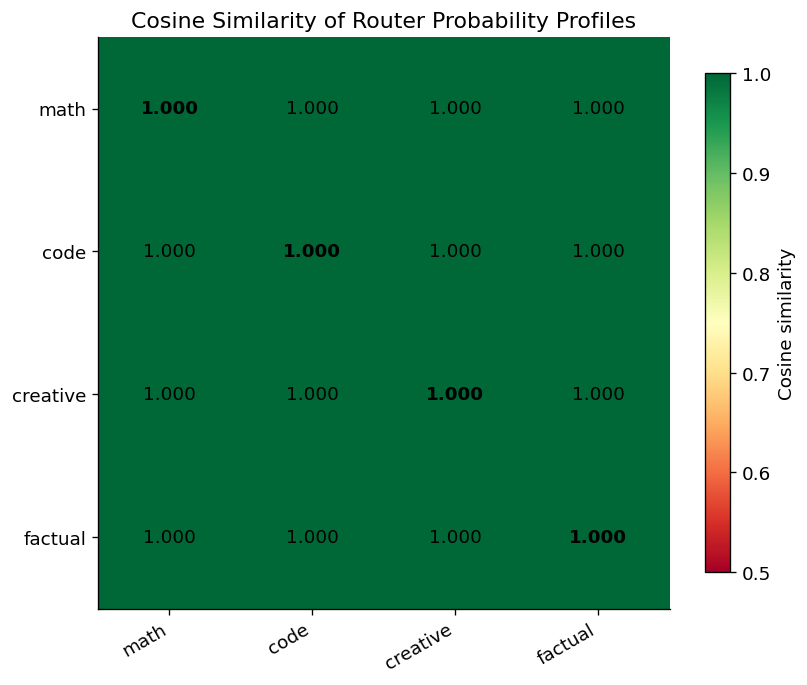

In [34]:
# Cosine similarity between routing profiles
profile_matrix = np.stack([profiles[pname] for pname in prompt_names])
sim_matrix = cosine_similarity(profile_matrix)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_matrix, cmap="RdYlGn", vmin=0.5, vmax=1.0)

# Annotate cells
for i in range(len(prompt_names)):
    for j in range(len(prompt_names)):
        ax.text(j, i, f"{sim_matrix[i, j]:.3f}",
                ha="center", va="center", fontsize=11,
                fontweight="bold" if i == j else "normal")

ax.set_xticks(range(len(prompt_names)))
ax.set_xticklabels(prompt_names, rotation=30, ha="right")
ax.set_yticks(range(len(prompt_names)))
ax.set_yticklabels(prompt_names)
ax.set_title("Cosine Similarity of Router Probability Profiles")
plt.colorbar(im, ax=ax, label="Cosine similarity", shrink=0.8)
plt.tight_layout()
plt.show()

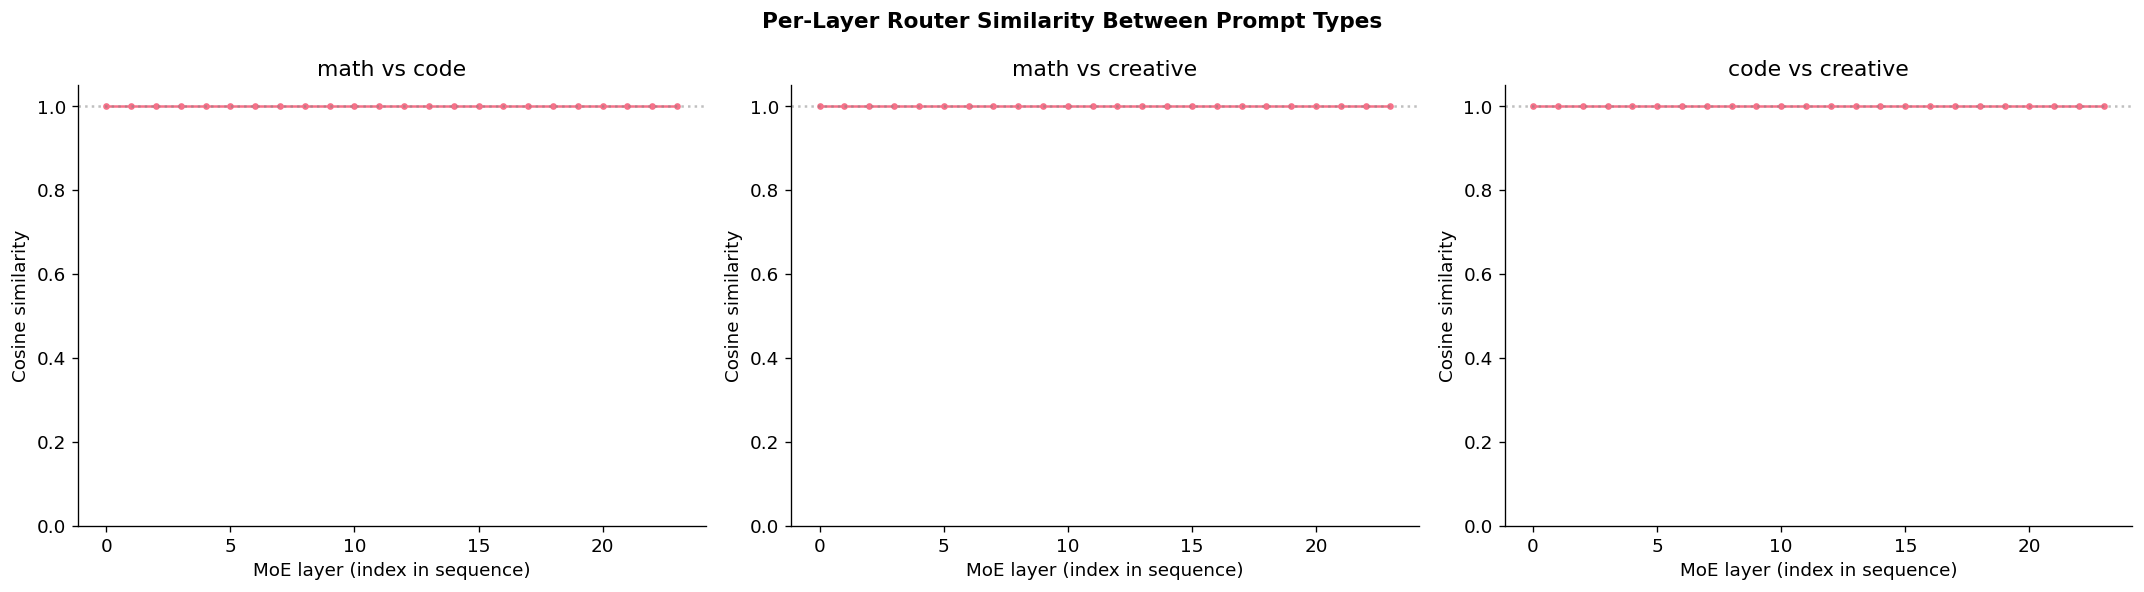

In [35]:
# Per-layer routing profile comparison: math vs code vs creative
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

comparisons = [
    ("math", "code"),
    ("math", "creative"),
    ("code", "creative"),
]

for ax, (pname_a, pname_b) in zip(axes, comparisons):
    profile_a, layers_a = compute_per_layer_routing_profile(
        all_routing_data[pname_a], num_experts_total
    )
    profile_b, layers_b = compute_per_layer_routing_profile(
        all_routing_data[pname_b], num_experts_total
    )

    # Compute per-layer cosine similarity
    num_comparable = min(len(layers_a), len(layers_b))
    layer_sims = []
    layer_labels = []
    for i in range(num_comparable):
        sim = cosine_similarity(profile_a[i:i+1], profile_b[i:i+1])[0, 0]
        layer_sims.append(sim)
        layer_labels.append(layers_a[i])

    ax.plot(range(num_comparable), layer_sims, "o-", markersize=3, linewidth=1.5)
    ax.axhline(y=1.0, color="gray", linestyle=":", alpha=0.5)
    ax.set_xlabel("MoE layer (index in sequence)")
    ax.set_ylabel("Cosine similarity")
    ax.set_title(f"{pname_a} vs {pname_b}")
    ax.set_ylim(0, 1.05)

plt.suptitle("Per-Layer Router Similarity Between Prompt Types", fontsize=13,
             fontweight="bold")
plt.tight_layout()
plt.show()

---

## 9. Routing Entropy per Layer

The entropy of the router's probability distribution tells us how "decisive" the
router is at each layer:

- **Low entropy**: the router strongly prefers specific experts (confident routing)
- **High entropy**: the router distributes probability more evenly (uncertain routing)

Maximum entropy for a uniform distribution over $N$ experts is $\log_2(N)$.

In [36]:
def compute_routing_entropy(routing_data, num_experts):
    """
    Compute the average entropy of the router distribution at each MoE layer.
    Returns:
        layer_indices: list of layer indices
        mean_entropies: (num_layers,) array of mean entropy values
        std_entropies: (num_layers,) array of entropy std across tokens
    """
    layer_indices = sorted(routing_data.keys())
    mean_entropies = []
    std_entropies = []

    for layer_idx in layer_indices:
        probs = routing_data[layer_idx]["probs"][0].numpy()  # (seq_len, num_experts)
        # Compute entropy for each token position (base 2 for bits)
        token_entropies = scipy_entropy(probs.T, base=2)  # (seq_len,)
        mean_entropies.append(np.mean(token_entropies))
        std_entropies.append(np.std(token_entropies))

    return layer_indices, np.array(mean_entropies), np.array(std_entropies)

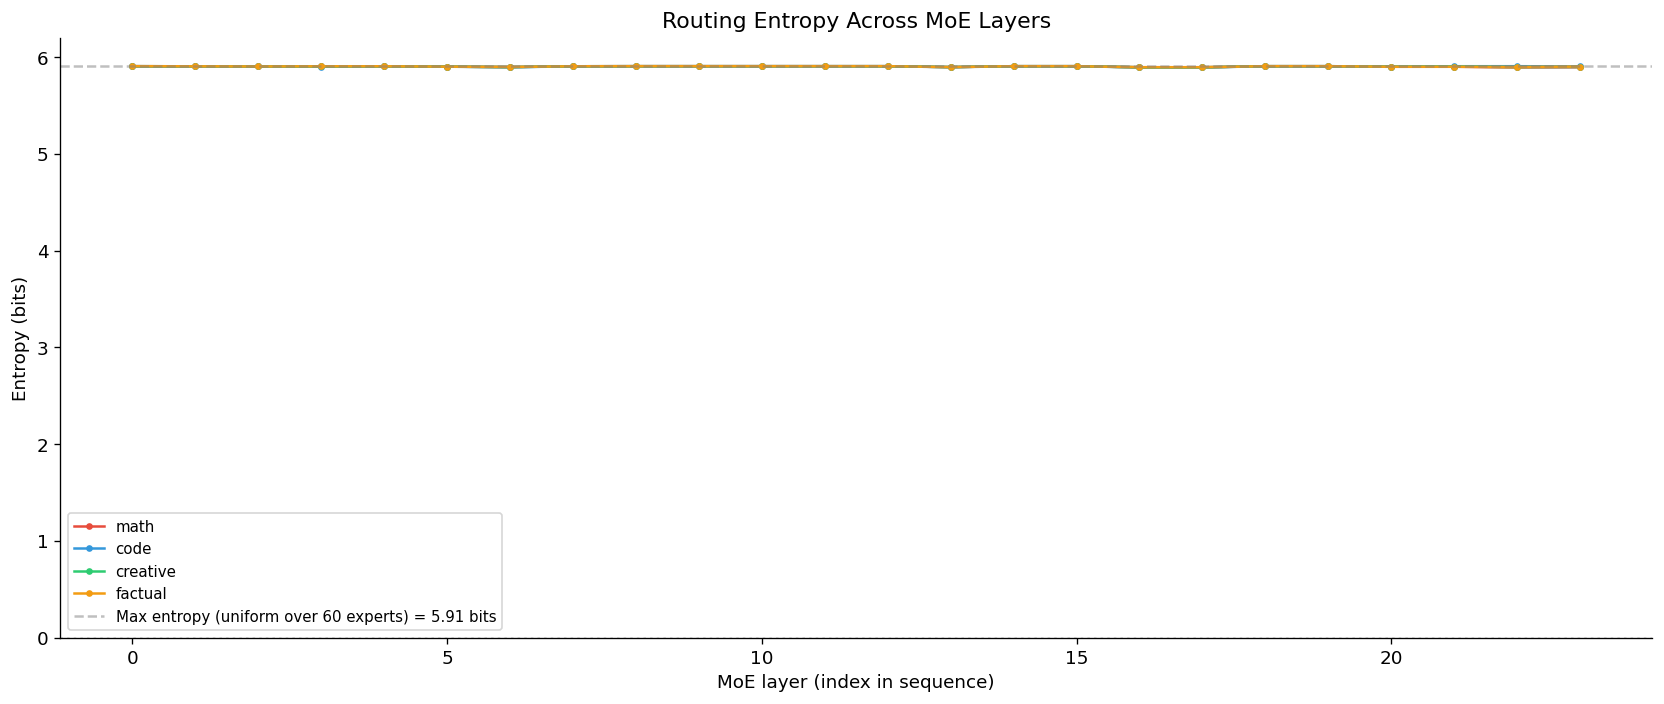

Maximum possible entropy (uniform over 60 experts): 5.907 bits

        math: mean entropy = 5.903 bits (99.9% of max), range [5.895, 5.907]
        code: mean entropy = 5.904 bits (100.0% of max), range [5.894, 5.907]
    creative: mean entropy = 5.903 bits (99.9% of max), range [5.896, 5.907]
     factual: mean entropy = 5.904 bits (99.9% of max), range [5.896, 5.907]


In [37]:
max_entropy = np.log2(num_experts_total)

fig, ax = plt.subplots(figsize=(14, 6))

prompt_colors_map = {
    "math": "#e74c3c",
    "code": "#3498db",
    "creative": "#2ecc71",
    "factual": "#f39c12",
}

for pname in prompt_names:
    layers, means, stds = compute_routing_entropy(
        all_routing_data[pname], num_experts_total
    )
    x = range(len(layers))
    color = prompt_colors_map[pname]
    ax.plot(x, means, "o-", label=pname, color=color, markersize=3, linewidth=1.5)
    ax.fill_between(x, means - stds, means + stds, alpha=0.15, color=color)

# Reference lines
ax.axhline(y=max_entropy, color="gray", linestyle="--", alpha=0.5,
           label=f"Max entropy (uniform over {num_experts_total} experts) = {max_entropy:.2f} bits")
ax.axhline(y=0, color="gray", linestyle=":", alpha=0.3)

ax.set_xlabel("MoE layer (index in sequence)")
ax.set_ylabel("Entropy (bits)")
ax.set_title("Routing Entropy Across MoE Layers")
ax.legend(loc="best", fontsize=9)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

print(f"Maximum possible entropy (uniform over {num_experts_total} experts): {max_entropy:.3f} bits")
print()
for pname in prompt_names:
    layers, means, stds = compute_routing_entropy(
        all_routing_data[pname], num_experts_total
    )
    print(f"{pname:>12}: mean entropy = {means.mean():.3f} bits "
          f"({means.mean() / max_entropy * 100:.1f}% of max), "
          f"range [{means.min():.3f}, {means.max():.3f}]")

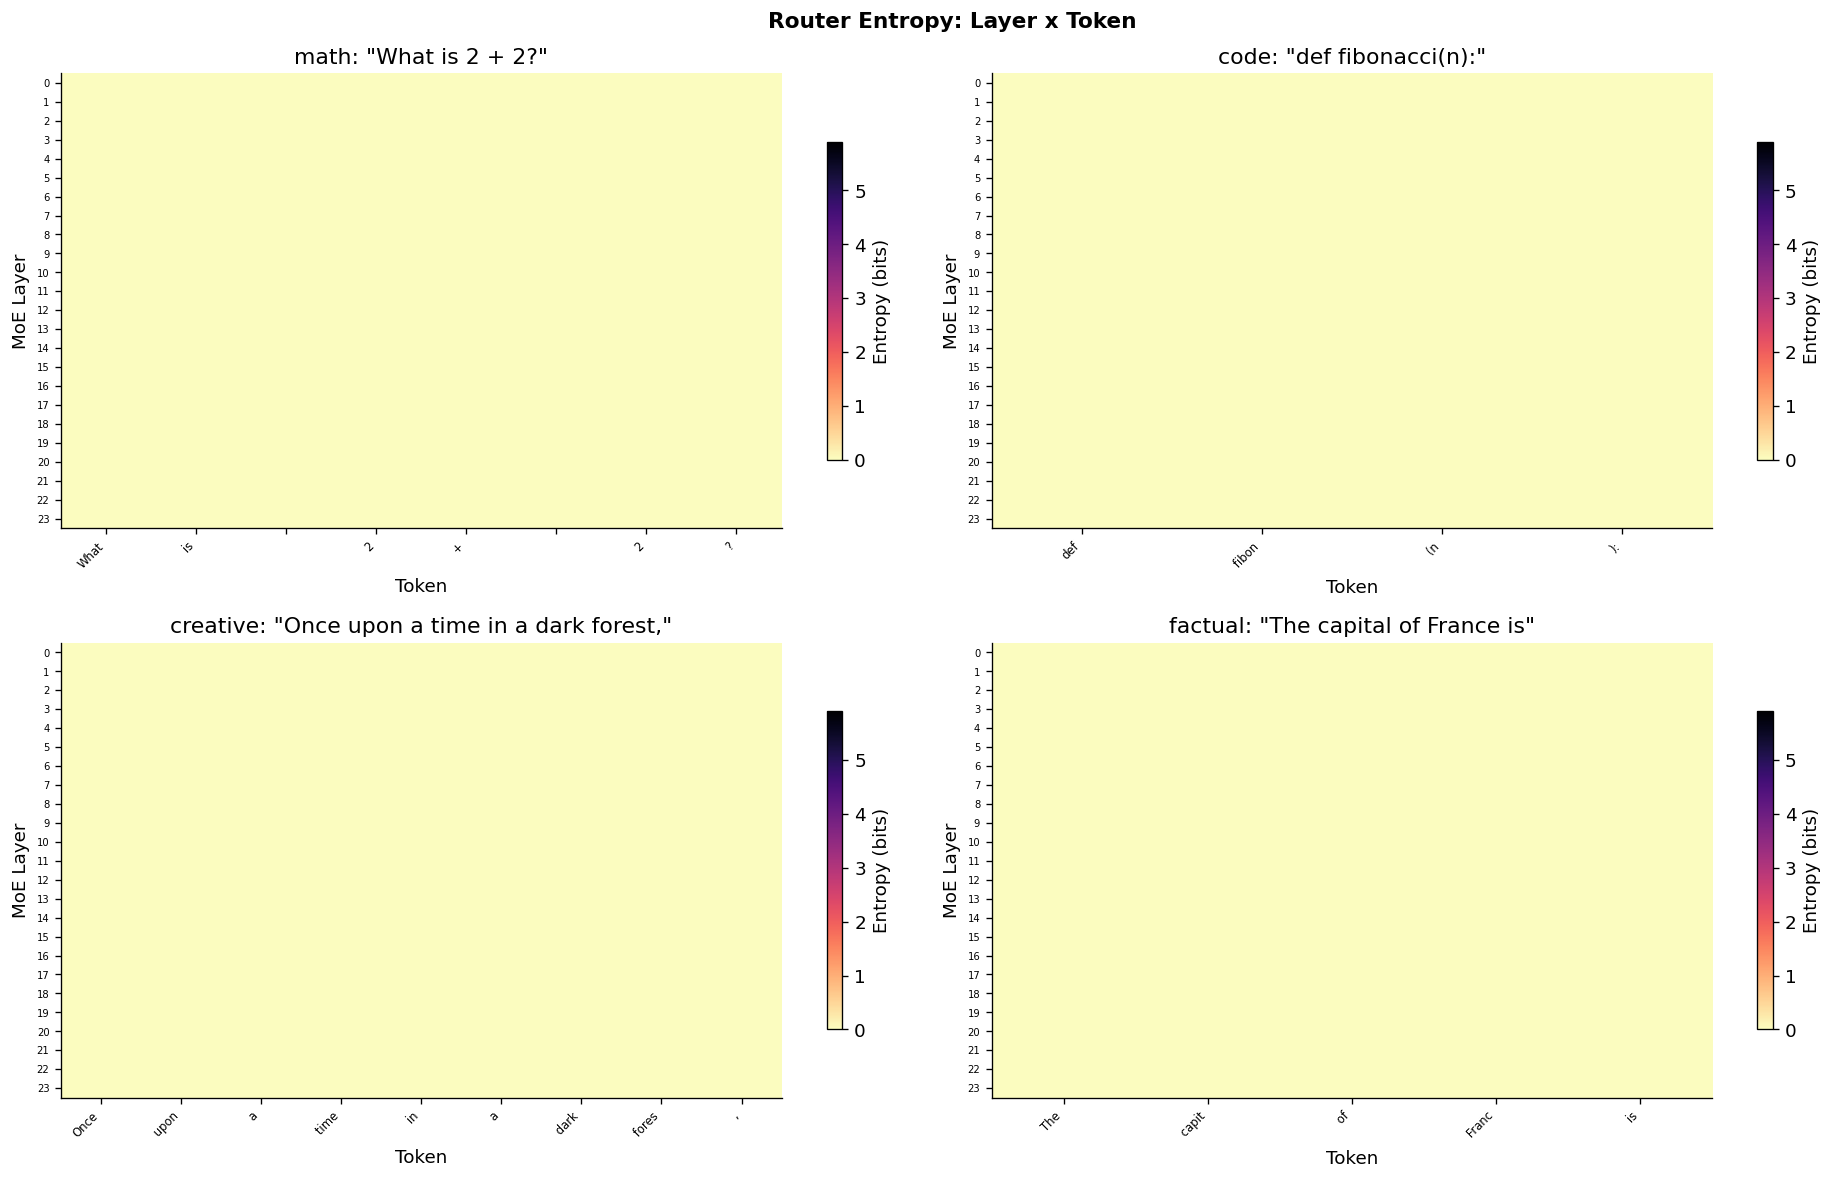

In [38]:
# Entropy heatmap: layer x token for each prompt
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, pname in zip(axes.flat, prompt_names):
    routing_data = all_routing_data[pname]
    layer_indices = sorted(routing_data.keys())
    tokens = all_tokens[pname]
    num_tokens = len(tokens)

    # Sample layers if too many
    if len(layer_indices) > 20:
        step = max(1, len(layer_indices) // 20)
        sampled_layers = layer_indices[::step]
    else:
        sampled_layers = layer_indices

    entropy_matrix = np.zeros((len(sampled_layers), num_tokens))
    for row, layer_idx in enumerate(sampled_layers):
        probs = routing_data[layer_idx]["probs"][0].numpy()  # (seq_len, num_experts)
        for tok in range(num_tokens):
            entropy_matrix[row, tok] = scipy_entropy(probs[tok], base=2)

    im = ax.imshow(entropy_matrix, aspect="auto", cmap="magma_r",
                    vmin=0, vmax=max_entropy, interpolation="nearest")
    ax.set_xlabel("Token")
    ax.set_ylabel("MoE Layer")
    ax.set_title(f"{pname}: \"{prompts[pname][:35]}...\"" if len(prompts[pname]) > 35
                 else f"{pname}: \"{prompts[pname]}\"")
    truncated = [t[:6] for t in tokens]
    ax.set_xticks(range(num_tokens))
    ax.set_xticklabels(truncated, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(sampled_layers)))
    ax.set_yticklabels(sampled_layers, fontsize=6)
    plt.colorbar(im, ax=ax, label="Entropy (bits)", shrink=0.7)

plt.suptitle("Router Entropy: Layer x Token", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---

## Summary

In this notebook we loaded a real Mixture of Experts model and visualized its
expert routing behavior in action:

1. **Model Loading** -- loaded Qwen1.5-MoE-A2.7B-Chat (or Mixtral fallback)
   and inspected its MoE architecture.
2. **Architecture Inspection** -- enumerated MoE layers, gate shapes, number
   of experts, and active expert count per token.
3. **Router Hooks** -- registered forward hooks to intercept routing decisions
   (logits, probabilities, and top-k selections).
4. **Inference Capture** -- ran four different prompt types (math, code,
   creative, factual) and captured all routing data.
5. **Activation Heatmaps** -- visualized which experts "light up" for each
   token at each layer, for both top-1 and top-2 selections.
6. **Expert Utilization** -- measured how evenly experts are used across
   prompts and layers.
7. **Token-Level Routing** -- created annotated maps showing exactly which
   expert handles each token at each layer.
8. **Similarity Analysis** -- compared routing patterns between prompt types
   using cosine similarity, revealing how different input domains activate
   different expert subsets.
9. **Routing Entropy** -- measured how decisive the router is at each layer,
   showing that some layers route confidently while others are more uncertain.

---

## 10. Further MoE Analysis

### 10.1 Expert-to-Expert Weight Cosine Similarity

This analysis compares the internal weight vectors of different experts within a single MoE layer. High cosine similarity suggests that two experts might be learning similar transformations or are specialized for very similar input features, potentially indicating redundancy or a lack of fine-grained specialization. Low similarity would imply distinct roles.

Inspecting module: Qwen2MoeSparseMoeBlock
Children of moe_block_to_inspect: ['gate', 'experts', 'shared_expert', 'shared_expert_gate']
Inspecting Qwen2MoeExperts wrapper: Qwen2MoeExperts
Children of qwen_experts_wrapper: ['act_fn']
qwen_experts_wrapper._modules: {'act_fn': SiLUActivation()}
qwen_experts_wrapper.__dict__.keys(): dict_keys(['training', '_parameters', '_buffers', '_non_persistent_buffers_set', '_backward_pre_hooks', '_backward_hooks', '_is_full_backward_hook', '_forward_hooks', '_forward_hooks_with_kwargs', '_forward_hooks_always_called', '_forward_pre_hooks', '_forward_pre_hooks_with_kwargs', '_state_dict_hooks', '_state_dict_pre_hooks', '_load_state_dict_pre_hooks', '_load_state_dict_post_hooks', '_modules', 'num_experts', 'hidden_dim', 'intermediate_dim', 'config', 'has_bias', 'is_transposed', '_is_hf_initialized'])
Detected intermediate_size from shared_expert: 5632
Found 'gate_up_proj' attribute in Qwen2MoeExperts wrapper. Its type is: <class 'torch.nn.parameter.Para

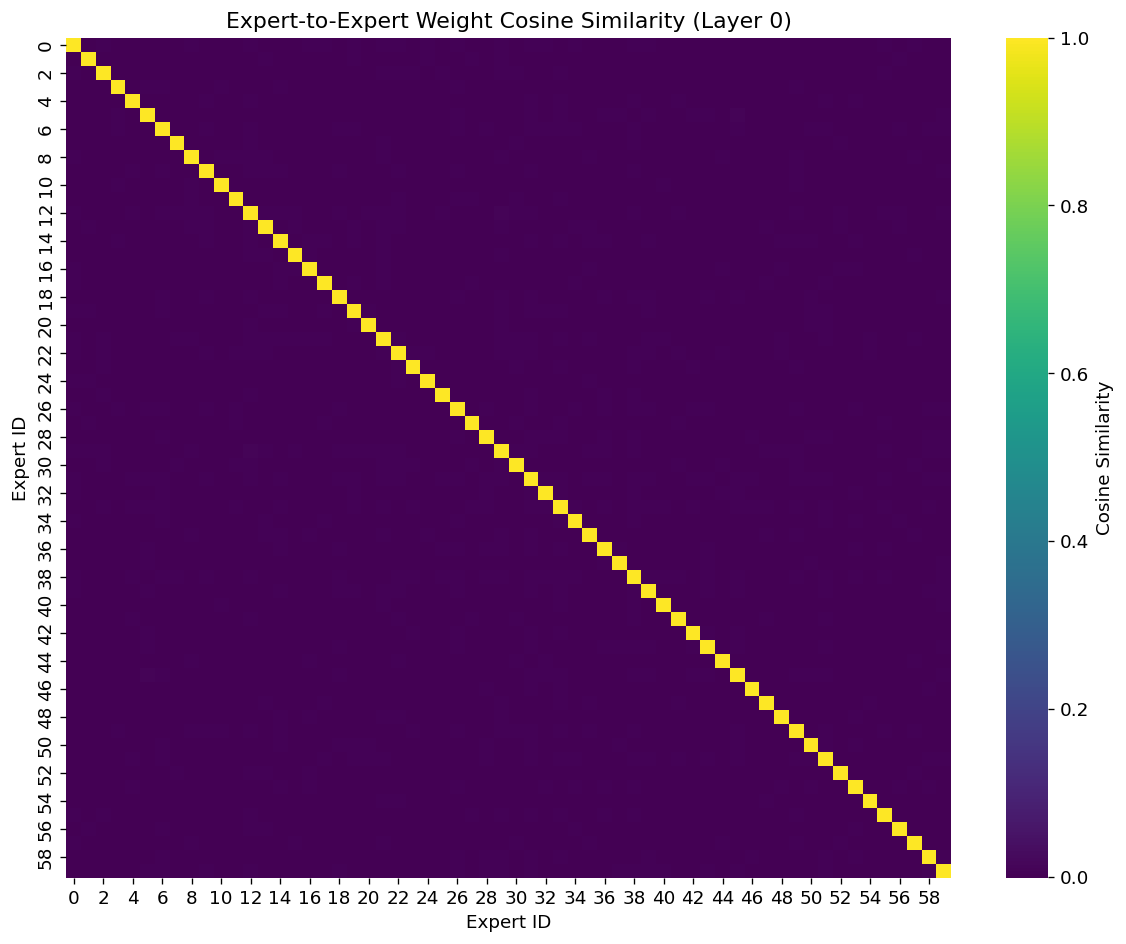

In [61]:
# Extract expert weights from the first MoE layer
layer_idx_to_inspect = moe_layers_info[0][0] # First MoE layer
moe_block_to_inspect = moe_layers_info[0][1]

expert_weights = []
actual_expert_modules = []

try:
    print(f"Inspecting module: {moe_block_to_inspect.__class__.__name__}")
    print(f"Children of moe_block_to_inspect: {[n for n, _ in moe_block_to_inspect.named_children()]}")

    qwen_experts_wrapper = getattr(moe_block_to_inspect, 'experts', None)

    if qwen_experts_wrapper is None:
        print("moe_block_to_inspect.experts attribute not found or is None. Skipping similarity analysis.")
    else:
        print(f"Inspecting Qwen2MoeExperts wrapper: {qwen_experts_wrapper.__class__.__name__}")
        print(f"Children of qwen_experts_wrapper: {[n for n, _ in qwen_experts_wrapper.named_children()]}")

        if hasattr(qwen_experts_wrapper, '_modules'):
            print(f"qwen_experts_wrapper._modules: {qwen_experts_wrapper._modules}")
        if hasattr(qwen_experts_wrapper, '__dict__'):
            print(f"qwen_experts_wrapper.__dict__.keys(): {qwen_experts_wrapper.__dict__.keys()}")

        # Try to extract intermediate_size from shared_expert
        # Note: The intermediate_size from shared_expert might not directly apply to the dimensions of W_gate_up
        # if it's already reshaped for experts. We will derive the expert_proj_intermediate_size from W_gate_up shape.
        intermediate_size_from_shared = None
        if hasattr(moe_block_to_inspect, 'shared_expert') and \
           hasattr(moe_block_to_inspect.shared_expert, 'gate_proj'):
            intermediate_size_from_shared = moe_block_to_inspect.shared_expert.gate_proj.weight.shape[0]
            print(f"Detected intermediate_size from shared_expert: {intermediate_size_from_shared}")

        W_gate_up = None
        if hasattr(qwen_experts_wrapper, 'gate_up_proj'):
            print(f"Found 'gate_up_proj' attribute in Qwen2MoeExperts wrapper. Its type is: {type(qwen_experts_wrapper.gate_up_proj)}")

            if isinstance(qwen_experts_wrapper.gate_up_proj, torch.nn.Module):
                if hasattr(qwen_experts_wrapper.gate_up_proj, 'weight'):
                    print("gate_up_proj is an nn.Module with a 'weight' attribute. Using it.")
                    W_gate_up = qwen_experts_wrapper.gate_up_proj.weight.data
                else:
                    print("gate_up_proj is an nn.Module but has no 'weight' attribute. Cannot use for expert weights.")
            elif isinstance(qwen_experts_wrapper.gate_up_proj, torch.Tensor):
                print("gate_up_proj is a torch.Tensor. Using it directly as weights.")
                W_gate_up = qwen_experts_wrapper.gate_up_proj.data # .data for potentially requiring grad, or just the tensor itself
            else:
                print(f"gate_up_proj is neither an nn.Module nor a torch.Tensor ({type(qwen_experts_wrapper.gate_up_proj)}). Cannot use for expert weights.")
        else:
            print("Could not find 'gate_up_proj' attribute in Qwen2MoeExperts. Cannot extract expert weights.")


        if W_gate_up is not None:
            print("Proceeding with expert weight extraction using W_gate_up.")
            print(f"W_gate_up actual shape: {W_gate_up.shape}")

            # Assuming W_gate_up is (num_experts, 2 * expert_proj_intermediate_size, hidden_size)
            # And the gate_proj is the first half of the second dimension.
            if W_gate_up.shape[1] % 2 != 0:
                print(f"Warning: Second dimension of W_gate_up ({W_gate_up.shape[1]}) is not divisible by 2. Cannot extract gate_proj as first half.")
                print("Skipping similarity analysis.")
            else:
                expert_proj_intermediate_size = W_gate_up.shape[1] // 2
                print(f"Derived expert_proj_intermediate_size from W_gate_up shape: {expert_proj_intermediate_size}")

                for i in range(num_experts_total):
                    # Direct index for expert 'i' in the first dimension
                    # Slice the 'gate_proj' part from the second dimension
                    expert_gate_proj_weight = W_gate_up[i, :expert_proj_intermediate_size, :]

                    if expert_gate_proj_weight.numel() == 0:
                        print(f"Warning: Expert {i} gate_proj slice is empty! Slice: [:, 0:{expert_proj_intermediate_size}, :], W_gate_up.shape={W_gate_up.shape}")
                    expert_weights.append(expert_gate_proj_weight.flatten().cpu().numpy())

                print(f"Successfully extracted {len(expert_weights)} expert weight vectors.")
        else:
            print("W_gate_up could not be successfully determined. Skipping similarity analysis.")

except Exception as e:
    print(f"An unexpected error occurred during expert weight extraction: {e}. Skipping similarity analysis.")


if not expert_weights:
    print("Could not extract expert weights. Skipping similarity analysis.")
else:
    expert_weights_matrix = np.array(expert_weights)
    # Compute cosine similarity between expert weight vectors
    expert_sim_matrix = cosine_similarity(expert_weights_matrix)

    # Plot the similarity matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(expert_sim_matrix, cmap="viridis", annot=False, fmt=".2f", cbar_kws={'label': 'Cosine Similarity'})
    plt.title(f"Expert-to-Expert Weight Cosine Similarity (Layer {layer_idx_to_inspect})")
    plt.xlabel("Expert ID")
    plt.ylabel("Expert ID")
    plt.tight_layout()
    plt.show()

In [54]:
print("\nFull Model Architecture (first 50 lines):\n" + "=" * 60)
count = 0
for name, module in model.named_modules():
    if count < 50:
        print(f"  {name}: {module.__class__.__name__}")
        count += 1
    else:
        break
if count == 50:
    print("  ...")

print("\nArchitecture of the first MoE block (moe_block_to_inspect):\n" + "=" * 60)
for name, module in moe_block_to_inspect.named_modules():
    print(f"  {name}: {module.__class__.__name__}")


Full Model Architecture (first 50 lines):
  : Qwen2MoeForCausalLM
  model: Qwen2MoeModel
  model.embed_tokens: Embedding
  model.layers: ModuleList
  model.layers.0: Qwen2MoeDecoderLayer
  model.layers.0.self_attn: Qwen2MoeAttention
  model.layers.0.self_attn.q_proj: Linear
  model.layers.0.self_attn.k_proj: Linear
  model.layers.0.self_attn.v_proj: Linear
  model.layers.0.self_attn.o_proj: Linear
  model.layers.0.mlp: Qwen2MoeSparseMoeBlock
  model.layers.0.mlp.gate: Qwen2MoeTopKRouter
  model.layers.0.mlp.experts: Qwen2MoeExperts
  model.layers.0.mlp.experts.act_fn: SiLUActivation
  model.layers.0.mlp.shared_expert: Qwen2MoeMLP
  model.layers.0.mlp.shared_expert.gate_proj: Linear
  model.layers.0.mlp.shared_expert.up_proj: Linear
  model.layers.0.mlp.shared_expert.down_proj: Linear
  model.layers.0.mlp.shared_expert.act_fn: SiLUActivation
  model.layers.0.mlp.shared_expert_gate: Linear
  model.layers.0.input_layernorm: Qwen2MoeRMSNorm
  model.layers.0.post_attention_layernorm: Qwen2

### 10.2 Token Expert Path Diversity

This visualization shows, for each token in each prompt, how many *unique* experts it was routed to across all MoE layers. A higher number indicates that the token engaged with a more diverse set of specialized components throughout the model, suggesting its processing path was complex or required input from various domains. A lower number suggests a more consistent, perhaps simpler, processing path involving a limited set of experts.

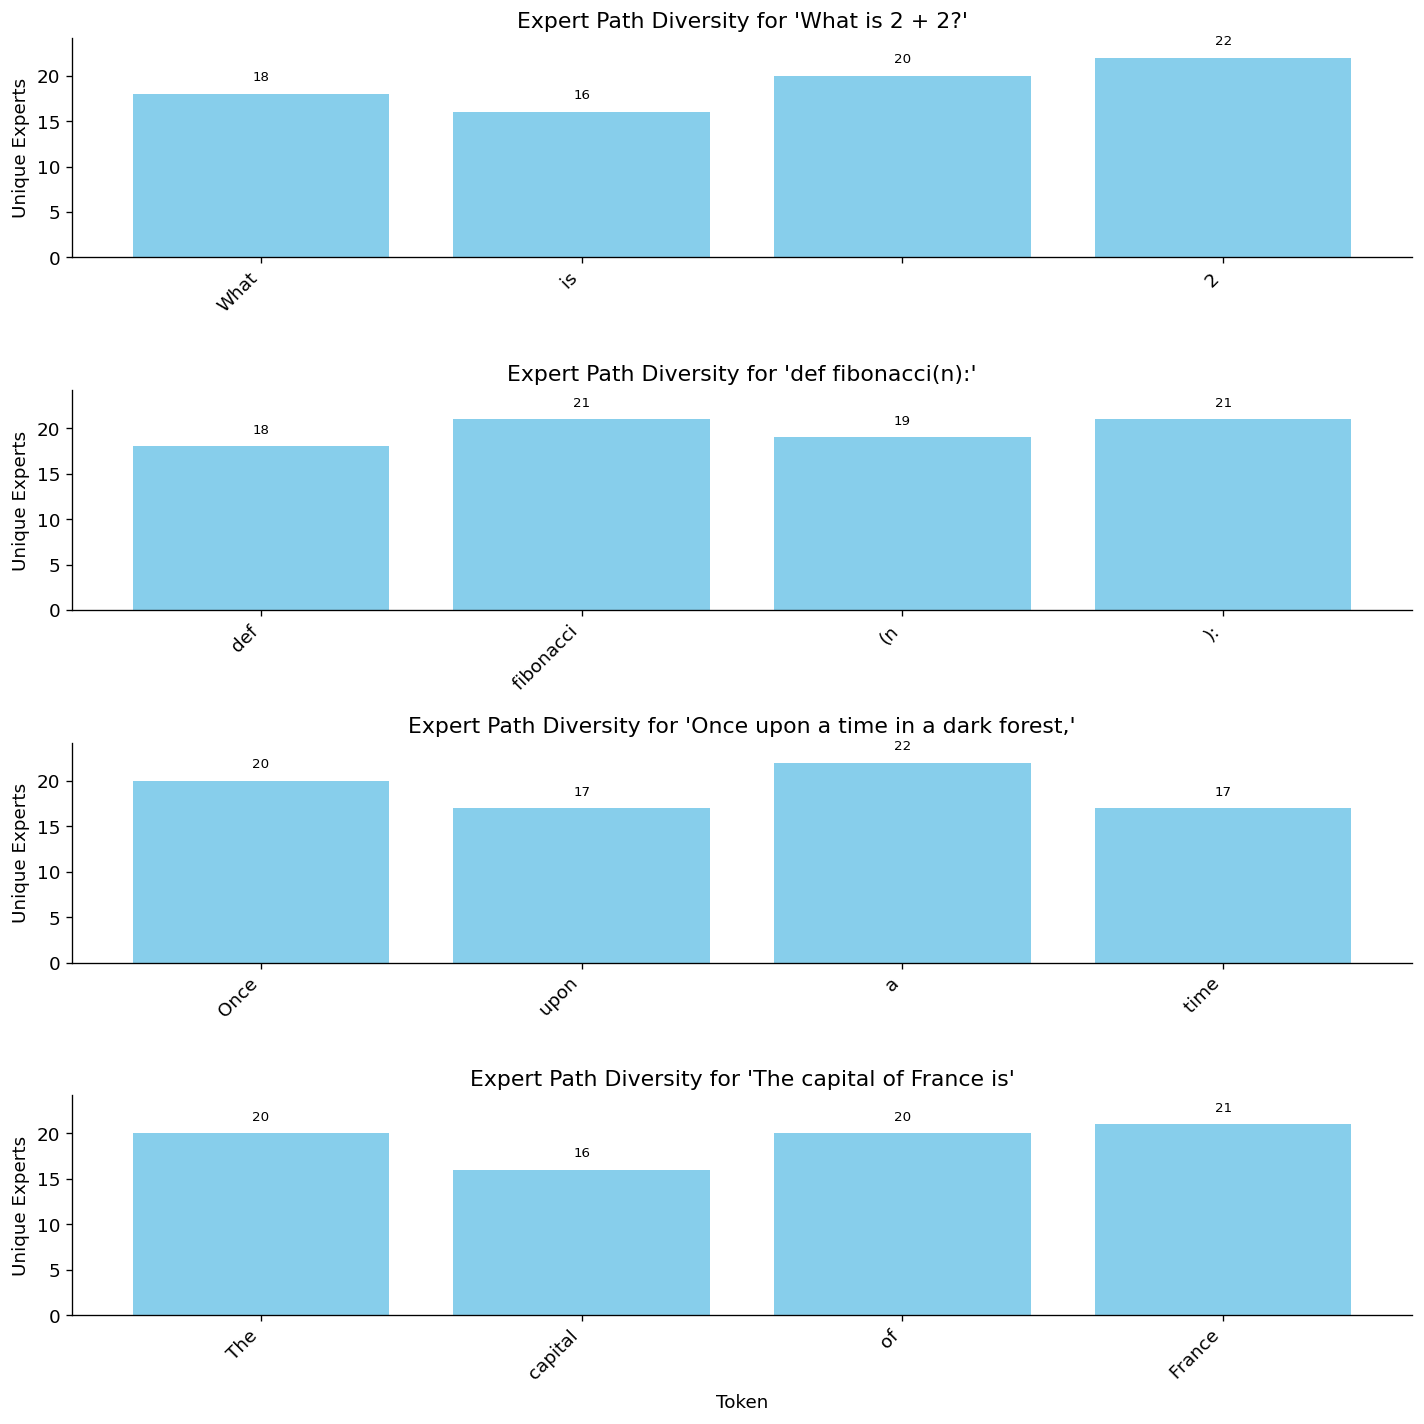

In [62]:
def compute_token_expert_diversity(all_routing_data, all_tokens):
    """
    Computes the number of unique experts visited by each token across all layers.
    Returns: dict of prompt_name -> list of unique_expert_counts per token
    """
    token_diversity = {}

    for prompt_name, routing_data in all_routing_data.items():
        # Get the actual sequence length processed by the model from the routing data
        # All layers should have the same sequence length for a given prompt
        first_layer_idx = sorted(routing_data.keys())[0]
        model_processed_seq_len = routing_data[first_layer_idx]["top_k_indices"][0].shape[0]

        # Initialize a set of unique experts for each token based on model_processed_seq_len
        unique_experts_per_token = [set() for _ in range(model_processed_seq_len)]

        for layer_idx in sorted(routing_data.keys()):
            data = routing_data[layer_idx]
            indices_for_layer = data["top_k_indices"][0].cpu().numpy() # (model_processed_seq_len, top_k)

            for tok_idx in range(model_processed_seq_len): # Iterate up to the model's processed length
                unique_experts_per_token[tok_idx].update(indices_for_layer[tok_idx].flatten())

        token_diversity[prompt_name] = [len(s) for s in unique_experts_per_token]
    return token_diversity

token_expert_diversity = compute_token_expert_diversity(all_routing_data, all_tokens)

# Plotting the token expert diversity
fig, axes = plt.subplots(len(prompts), 1, figsize=(12, 3 * len(prompts)), sharex=False)

if len(prompts) == 1: # Handle case with only one prompt to avoid axes being a single object
    axes = [axes]

max_unique_experts = 0 # To set a consistent y-limit
for pname in prompts:
    max_unique_experts = max(max_unique_experts, max(token_expert_diversity[pname]))

for i, prompt_name in enumerate(prompts):
    ax = axes[i]
    diversity_counts = token_expert_diversity[prompt_name]

    # Use the truncated tokens for plotting that correspond to the model's processed length
    first_layer_idx = sorted(all_routing_data[prompt_name].keys())[0]
    model_processed_seq_len = all_routing_data[prompt_name][first_layer_idx]["top_k_indices"][0].shape[0]
    tokens_for_plotting = all_tokens[prompt_name][:model_processed_seq_len]

    bars = ax.bar(range(len(tokens_for_plotting)), diversity_counts, color='skyblue')
    ax.set_title(f"Expert Path Diversity for '{prompts[prompt_name]}'")
    ax.set_ylabel("Unique Experts")
    ax.set_xticks(range(len(tokens_for_plotting)))
    truncated = [t.replace("\n", "\\n")[:10] for t in tokens_for_plotting]
    ax.set_xticklabels(truncated, rotation=45, ha="right")
    ax.set_ylim(0, max_unique_experts * 1.1) # Add some padding

    # Add values on top of bars
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.05 * max_unique_experts, round(yval, 1),
                ha='center', va='bottom', fontsize=8)

plt.xlabel("Token")
plt.tight_layout()
plt.show()

### Relationship between Expert Weight Distinctness and Path Diversity

The two concepts of **Distinct Weights** and **Expert Path Diversity** are closely related and reinforce each other in understanding MoE models:

*   **Distinct Weights**: Our previous analysis of 'Expert-to-Expert Weight Cosine Similarity' showed that the internal weight vectors of the experts are quite distinct. This implies that each expert has learned to perform a different kind of transformation or specializes in processing different types of input features or patterns. They act as truly different 'specialists' within the model.

*   **Expert Path Diversity**: This analysis visualizes how many *unique* experts a single token is routed through across all the MoE layers. If a token exhibits high path diversity, it means it engages with many different specialists during its journey through the model.

**How they relate**: If the experts themselves are highly distinct (as we observed), then a high expert path diversity for a token implies that the processing of that token is genuinely complex and requires input from a variety of *different* specialized modules. It suggests the token is being 'handed off' to various specialists, with each contributing its unique knowledge or transformation. If the experts were not distinct, then even high path diversity might not be as meaningful, as the token would simply be processed by many similar experts. Therefore, the distinctness of the experts makes the diversity in routing paths a more potent indicator that the model is effectively leveraging its specialized components for fine-grained and varied processing.

## Identifying Expert Scenarios

To identify what scenarios the most frequently used experts are utilized for, you would generally need to perform a more in-depth analysis of the inputs that trigger these experts. This can involve:

1.  **Input Categorization**: Manually or semi-automatically categorizing the tokens or segments of input text that consistently route to these highly utilized experts. For example, if a certain expert is always active when mathematical symbols or numerical tokens appear, it suggests a role in numerical processing.
2.  **Prompt Engineering**: Designing specific prompts intended to isolate certain functionalities (e.g., asking only mathematical questions, only code generation tasks, or only factual retrieval queries) and then observing which experts are predominantly activated.
3.  **Feature Attribution Methods**: Using techniques from explainable AI to understand which features in the input are most influential in routing decisions to these experts.
4.  **Expert Output Inspection**: If possible, inspecting the actual transformations performed by the expert (though this can be complex due to the black-box nature of neural networks).

By systematically varying inputs and observing the routing patterns to these top experts, you can start to infer their functional specializations.

In [65]:
# Get the indices of experts sorted by their overall usage count in descending order
sorted_expert_indices = np.argsort(overall_counts)[::-1]

# Display the top 5 most frequently used experts
print("Top 5 Most Frequently Used Experts Across All Layers:")
for i in range(5):
    expert_id = sorted_expert_indices[i]
    count = overall_counts[expert_id]
    print(f"  Expert ID {expert_id}: {int(count)} times")


Top 5 Most Frequently Used Experts Across All Layers:
  Expert ID 52: 22 times
  Expert ID 57: 14 times
  Expert ID 51: 14 times
  Expert ID 40: 14 times
  Expert ID 39: 13 times


In [ ]:
# Clean up
capture.remove_hooks()
print("Hooks removed. Done.")